data explation

In [1]:
import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')

# 显示前几行数据，以确认导入是否正确
df.head()


,order_id,customer_id,ip_addr,date_created,date_paid,total,status,items
0,11787,517,81741da2cc0e5207bfefbb4ec257b2393d5e13a0,2021-04-14 05:56:06,2021-04-14 05:56:37,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
1,40606,519,ccf5e36bddfbce1a7de2c04874190a057b30588d,2024-03-05 10:16:40,2024-03-05 10:17:23,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
2,40488,519,ccf5e36bddfbce1a7de2c04874190a057b30588d,2024-03-01 11:40:20,2024-03-01 11:40:58,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
3,38252,519,1f8e636af94847a55418d2c03ccf4b1601d10512,2023-12-05 08:48:02,2023-12-05 08:49:24,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
4,13470,776,d4c84c8e50cf80cc385d669000208e59e304fcca,2021-06-20 12:10:17,2021-06-20 12:11:09,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."


In [2]:
df.count()

order_id        36019
customer_id     36019
ip_addr         36019
date_created    36019
date_paid       36019
total           36019
status          36019
items           36019
dtype: int64

Average Order Value

In [3]:
# 计算总体的aov
# 计算总收入
total_revenue = df['total'].sum()

# 计算总订单数
total_orders = df['order_id'].nunique()

# 计算平均订单价值
aov = total_revenue / total_orders
print(f"Average Order Value: {aov:.2f}")


Average Order Value: 947.15


In [4]:
# 计算每个月的aov
# 确保 order_date 是 datetime 格式
df['order_date'] = pd.to_datetime(df['date_paid'])

# 提取月份信息
df['month'] = df['order_date'].dt.to_period('M')

# 按月计算总收入和订单数
monthly_revenue = df.groupby('month')['total'].sum()
monthly_orders = df.groupby('month')['order_id'].nunique()

# 计算每月的平均订单价值
monthly_aov = monthly_revenue / monthly_orders
print(monthly_aov)


month
2019-05     814.480769
2019-06    1294.285714
2019-07    1023.809524
2019-08     917.380952
2019-09     988.089888
2019-10     943.939394
2019-11     950.349650
2019-12     904.945055
2020-01    1031.666667
2020-02     924.897959
2020-03     921.857143
2020-04    1012.865497
2020-05    1021.885856
2020-06     987.816377
2020-07     957.572993
2020-08     980.550847
2020-09    1044.936869
2020-10     963.970081
2020-11     948.847858
2020-12     930.793951
2021-01    1025.928705
2021-02     934.389764
2021-03     917.926635
2021-04     930.243112
2021-05     947.291382
2021-06    1018.577291
2021-07    1008.573466
2021-08    1038.022250
2021-09    1080.091220
2021-10    1040.434783
2021-11    1001.209877
2021-12     975.220949
2022-01    1016.944444
2022-02     963.617607
2022-03     946.474279
2022-04     975.832224
2022-05     913.824940
2022-06     970.217096
2022-07     963.209877
2022-08     928.192771
2022-09     955.540904
2022-10     957.842365
2022-11     971.960272
2022-

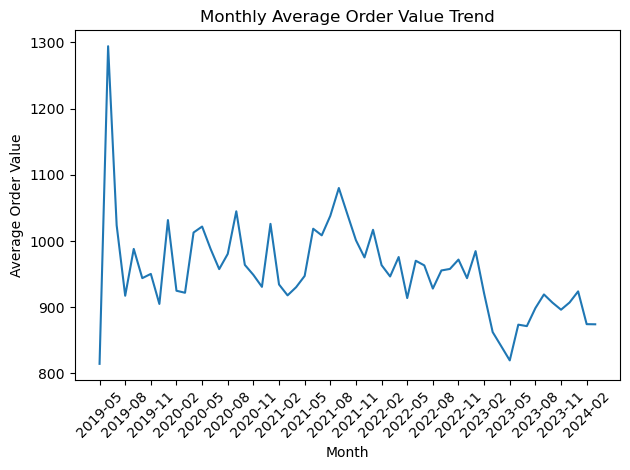

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设你已经有 monthly_aov 这个数据

# 绘制每月的 AOV 变化趋势图
plt.plot(monthly_aov.index.astype(str), monthly_aov.values)

# 设置 X 轴刻度间隔（每隔 3 个月显示一个标签，可以根据需求调整）
plt.xticks(ticks=range(0, len(monthly_aov), 3), labels=monthly_aov.index[::3].astype(str))

# 旋转 X 轴标签避免重叠
plt.xticks(rotation=45)

# 设置标题和标签
plt.xlabel('Month')
plt.ylabel('Average Order Value')
plt.title('Monthly Average Order Value Trend')

# 自动调整布局，避免标签遮挡
plt.tight_layout()

plt.show()


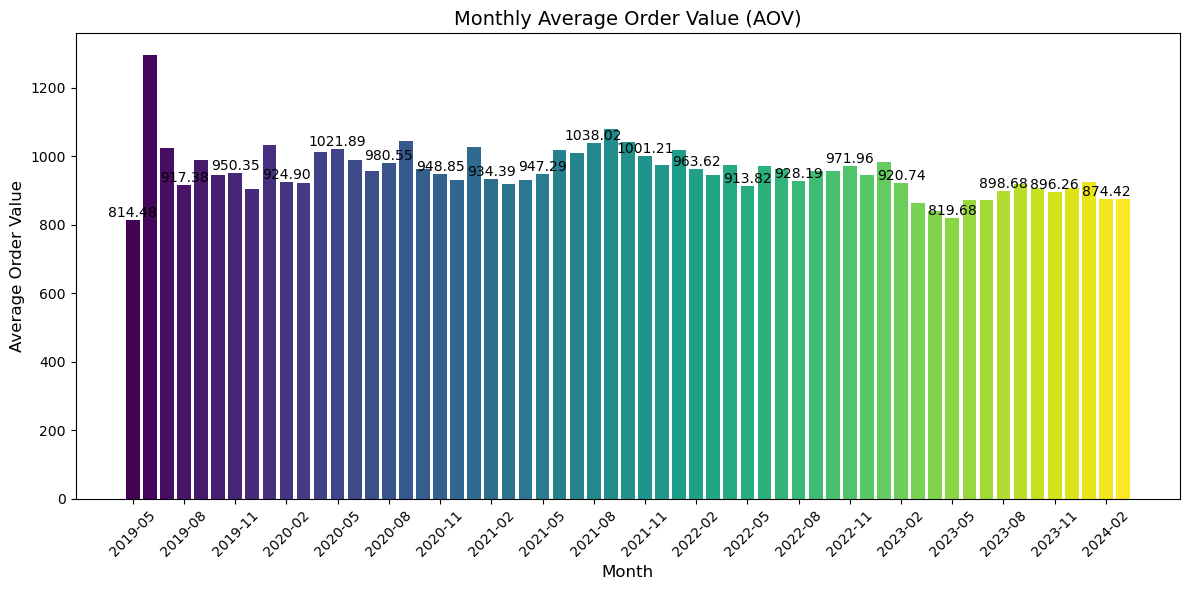

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 假设你已经有 monthly_aov 这个数据
months = monthly_aov.index.astype(str)
values = monthly_aov.values

# 设置不同颜色，使用 colormap 让颜色过渡自然
colors = plt.cm.viridis(np.linspace(0, 1, len(values)))

# 创建柱状图，增加图表宽度
plt.figure(figsize=(12, 6))  # 设置更宽的图表

# 创建柱状图
bars = plt.bar(months, values, color=colors)

# 添加标题和标签
plt.title('Monthly Average Order Value (AOV)', fontsize=14)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Order Value', fontsize=12)

# 设置 X 轴标签每隔 3 个月显示一次，调整 xticks
plt.xticks(ticks=range(0, len(months), 3), labels=months[::3], rotation=45, fontsize=10)

# 每隔几个柱子显示一次数值
for i, bar in enumerate(bars):
    if i % 3 == 0:  # 每隔3个柱子显示一次
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.2f}', ha='center', va='bottom', fontsize=10)

# 自动调整布局，避免标签遮挡
plt.tight_layout()

# 显示图表
plt.show()



Peak revenue hour

In [7]:
# Step 1: Convert order time to datetime and extract the hour

# First, ensure that your order_time column is in a datetime format, and then extract the hour from each timestamp.
import pandas as pd

# Sample data (order_time and revenue)
data = {'order_time': df['date_paid'],
        'revenue': df['total']}

df = pd.DataFrame(data)

# Convert order_time to datetime
df['order_time'] = pd.to_datetime(df['order_time'])

# Extract hour from the timestamp
df['hour'] = df['order_time'].dt.hour

In [8]:
# Step 2: Group the revenue by hour
# Group by hour and sum the revenue
hourly_revenue = df.groupby('hour')['revenue'].sum()

# Display the result
print(hourly_revenue)


hour
0        1350.0
1        1890.0
2        2110.0
4        5560.0
5      269694.0
6     3179114.0
7     6240376.0
8     7699909.0
9     6227790.0
10    4179411.0
11    2421998.0
12    1882742.0
13    1010831.0
14     576610.0
15     269835.0
16      10220.0
17      14930.0
18       3390.0
19      13920.0
20      16630.0
21      58228.0
22      19788.0
23       8970.0
Name: revenue, dtype: float64


In [9]:
# indentify the peak time hour
# Identify the peak revenue hour
peak_hour = hourly_revenue.idxmax()
peak_revenue = hourly_revenue.max()

print(f"Peak revenue hour: {peak_hour}:00 with a revenue of {peak_revenue}")


Peak revenue hour: 8:00 with a revenue of 7699909.0


we find the best revenue hour is 8 am everyday

In [10]:
import pandas as pd


df = pd.read_csv('dataprocesscompleted.csv')

In [11]:
import pandas as pd

# Sample data (customer_id, order_time, and revenue)
data = {'customer_id': df['customer_id'],
        'order_time': df['date_paid'],
        'revenue': df['total']}

# Create a DataFrame
df = pd.DataFrame(data)

# Group by customer_id and sum the revenue for each customer
customer_revenue = df.groupby('customer_id')['revenue'].sum()

# Calculate the average revenue per customer
average_revenue_per_customer = customer_revenue.mean()

# Display the total revenue per customer and the average revenue
print("Total revenue per customer:")
print(customer_revenue)
print(f"\nAverage revenue per customer: {average_revenue_per_customer:.2f}")


Total revenue per customer:
customer_id
4         1400.0
5        43916.0
6         4727.0
7         1310.0
8       127190.0
          ...   
1753       480.0
1754       530.0
1756       480.0
1757       480.0
1758      1030.0
Name: revenue, Length: 1596, dtype: float64

Average revenue per customer: 21375.50


# Product Analysis

In [12]:
import pandas as pd
import re
# read bigquery data into pandas dataframe
import pandas as pd

import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')

# # 显示前几行数据，以确认导入是否正确
# df.head()

# 示例数据（假设 'productitem' 列含有包含产品信息的字符串）
data = {'productitem': df['items']}

# 创建 DataFrame
df = pd.DataFrame(data)

# 定义一个函数，用正则表达式提取 'name' 后面的产品名字
def extract_product_names(productitem):
    # 使用正则表达式查找所有 'name' 后的值
    product_names = re.findall(r'"name":"(.*?)"', productitem)
    return product_names

# 应用函数解析 'productitem' 列，提取出商品名字
df['product_names'] = df['productitem'].apply(extract_product_names)

# 展开 'product_names' 列中的列表
df_exploded = df.explode('product_names')

# 查看解析后的数据
print(df_exploded[['productitem', 'product_names']])


                                             productitem product_names
0      {"cart_size":2,"cart_surcharge":0,"cart_total_...         Latte
0      {"cart_size":2,"cart_surcharge":0,"cart_total_...          size
0      {"cart_size":2,"cart_surcharge":0,"cart_total_...          Milk
0      {"cart_size":2,"cart_surcharge":0,"cart_total_...      Strength
0      {"cart_size":2,"cart_surcharge":0,"cart_total_...         Decaf
...                                                  ...           ...
36018  {"cart_size":2,"cart_surcharge":93,"cart_total...         Syrup
36018  {"cart_size":2,"cart_surcharge":93,"cart_total...   White Sugar
36018  {"cart_size":2,"cart_surcharge":93,"cart_total...     Raw Sugar
36018  {"cart_size":2,"cart_surcharge":93,"cart_total...   Equal Sugar
36018  {"cart_size":2,"cart_surcharge":93,"cart_total...    Extra shot

[640990 rows x 2 columns]


In [13]:
import pandas as pd


df = pd.read_csv('dataprocesscompleted.csv')

In [14]:
import pandas as pd
import re

# 示例数据（假设 'productitem' 列包含商品信息，某些行可能有 NaN）
data = {'productitem':df_exploded['product_names']}

# 创建 DataFrame
df = pd.DataFrame(data)

# 处理 NaN 值：将 NaN 转换为空字符串，避免处理空值时出错
df['productitem'] = df['productitem'].fillna('')

# 定义一个函数，用正则表达式提取 'name' 后的商品名字
def extract_product_names(productitem):
    # 确保 'productitem' 是字符串而非整个列
    if isinstance(productitem, str):
        # 使用正则表达式查找所有 'name' 后的值
        product_names = re.findall(r'"name":"(.*?)"', productitem)
        return product_names
    return []

# 确保 'productitem' 列是字符串类型，避免 float 类型的错误
df['productitem'] = df['productitem'].astype(str)

# 应用函数解析 'productitem' 列，逐行提取出商品名字
df['product_names'] = df['productitem'].apply(extract_product_names)

# 展开 'product_names' 列中的列表
df_exploded = df.explode('product_names')

# 查看解析后的数据
print(df_exploded[['productitem', 'product_names']])




       productitem product_names
0            Latte           NaN
0             size           NaN
0             Milk           NaN
0         Strength           NaN
0            Decaf           NaN
...            ...           ...
36018        Syrup           NaN
36018  White Sugar           NaN
36018    Raw Sugar           NaN
36018  Equal Sugar           NaN
36018   Extra shot           NaN

[640990 rows x 2 columns]


In [15]:
# 统计每个商品的销售数量
item_counts = df_exploded['productitem'].value_counts()

# 找出销量前 5 的商品
top_items = item_counts.head(5)

# 输出结果
print("Top 5 Best-Selling Items:")
print(top_items)

Top 5 Best-Selling Items:
productitem
size         70779
Milk         52585
Strength     49767
Syrup        49682
Raw Sugar    48862
Name: count, dtype: int64


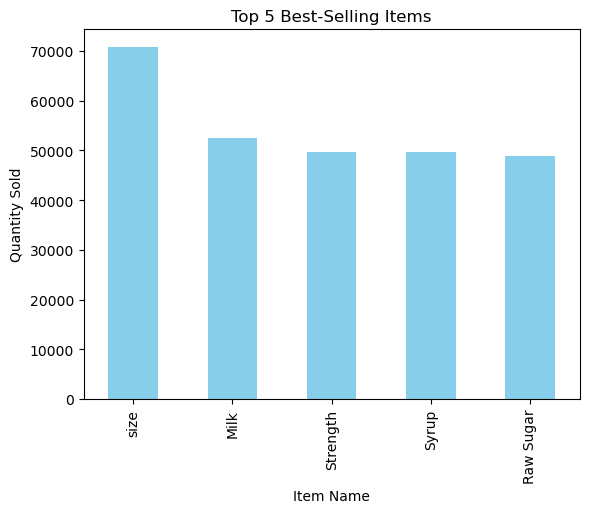

In [16]:
import matplotlib.pyplot as plt

# 绘制前 5 个畅销商品的柱状图
top_items.plot(kind='bar', color='skyblue')

# 添加标题和标签
plt.title('Top 5 Best-Selling Items')
plt.xlabel('Item Name')
plt.ylabel('Quantity Sold')

# 显示图表
plt.show()


In [17]:
# Determination of the average price per item.
import pandas as pd
import re
# read bigquery data into pandas dataframe
import pandas as pd


import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')

# # 显示前几行数据，以确认导入是否正确
# df.head()

import pandas as pd
import re

# 示例数据（假设 'productitem' 列包含商品信息）
data = {'productitem': df['items']}

# 创建 DataFrame
df = pd.DataFrame(data)

# 定义一个函数，提取商品的价格
def extract_product_prices(productitem):
    # 使用正则表达式查找所有 'price' 后的商品价格
    prices = re.findall(r'"price":(\d+)', productitem)
    # 将价格转换为整数
    return [int(price) for price in prices]

# 处理 NaN 值，将 NaN 转为空字符串
df['productitem'] = df['productitem'].fillna('')

# 确保 'productitem' 列是字符串类型
df['productitem'] = df['productitem'].astype(str)

# 应用函数提取商品价格
df['prices'] = df['productitem'].apply(extract_product_prices)

# 展开 'prices' 列，使每个价格独立成行
df_exploded = df.explode('prices')
# 将 'prices' 列转换为数值类型
df_exploded['prices'] = df_exploded['prices'].astype(float)

# 计算平均商品价格
average_price_per_item = df_exploded['prices'].mean()

# 输出平均商品价格
print(f"Average price per item: {average_price_per_item:.2f}")



Average price per item: 124.92


Correlation between average price and quantity sold

In [18]:
import pandas as pd
import re
import pandas as pd
import re
# read bigquery data into pandas dataframe
import pandas as pd


import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')

# 显示前几行数据，以确认导入是否正确
# df.head()

# 示例数据（假设 'productitem' 列包含商品信息）
data = {'productitem': df['items']}

# 创建 DataFrame
df = pd.DataFrame(data)

# 定义一个函数，提取商品名称和价格
def extract_product_info(productitem):
    # 使用正则表达式提取商品名称和价格
    product_names = re.findall(r'"name":"(.*?)"', productitem)
    prices = re.findall(r'"price":(\d+)', productitem)
    prices = [int(price) for price in prices]  # 将价格转换为整数
    return list(zip(product_names, prices))  # 返回商品名称和价格的元组列表

# 处理 NaN 值，将 NaN 转为空字符串
df['productitem'] = df['productitem'].fillna('')

# 确保 'productitem' 列是字符串类型
df['productitem'] = df['productitem'].astype(str)

# 提取商品信息 (名称和价格)
df['product_info'] = df['productitem'].apply(extract_product_info)

# 展开 'product_info' 列，使每个商品名称和价格成为独立的行
df_exploded = df.explode('product_info')

# 分离商品名称和价格
df_exploded['product_names'] = df_exploded['product_info'].apply(lambda x: x[0])
df_exploded['prices'] = df_exploded['product_info'].apply(lambda x: x[1])

# 统计每个商品的平均价格和销售数量
average_price_per_item = df_exploded.groupby('product_names')['prices'].mean()
quantity_sold_per_item = df_exploded['product_names'].value_counts()

# 将平均价格和销售数量合并为一个DataFrame
df_summary = pd.DataFrame({'average_price': average_price_per_item, 'quantity_sold': quantity_sold_per_item})

# 查看数据
print(df_summary)

# 计算二者的相关性
correlation = df_summary['average_price'].corr(df_summary['quantity_sold'])
print(f"\nCorrelation between average price and quantity sold: {correlation:.2f}")


                                         average_price  quantity_sold
product_names                                                        
(Entree) Pasta                             1097.333333             15
(Main) Pasta                               1423.076923             39
12-Hour Slow Cooked Pulled Pork            1884.736842             19
Acai Smoothie bowl (VO)                    1890.000000             13
Affogato                                    450.000000              5
...                                                ...            ...
White Hot Chocolate                         483.292683            328
White Sugar                                   0.000000          48862
Zucchini Corn Fritters with Bacon (GFO)    1890.000000              3
Zucchini Spaghetti & Meatballs             1677.500000             16
size                                         88.967067          70779

[112 rows x 2 columns]

Correlation between average price and quantity sold: -0.44


we find the price and quantity sold have a negative correlation

In [19]:
import pandas as pd
import re
# read bigquery data into pandas dataframe

import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
import pandas as pd

# Sample dataset containing customer_id and the date they made a payment
data = {
    'customer_id': df['customer_id'],
    'date_paid': df['date_paid']}

# Create DataFrame
df = pd.DataFrame(data)

# Convert 'date_paid' to datetime format
df['date_paid'] = pd.to_datetime(df['date_paid'])

# Extract year and month
df['year_month'] = df['date_paid'].dt.to_period('M')

# Step 1: Get the first payment date for each customer (indicating when they first became a customer)
df_first_payment = df.sort_values(by='date_paid').drop_duplicates(subset='customer_id', keep='first')

# Step 2: Calculate the number of customers at the start and end of each month

# Total customers at the end of each month (cumulative number of unique customers by the end of each month)
df_end_customers = df.groupby('year_month')['customer_id'].nunique().cumsum()

# Total new customers acquired in each month
df_new_customers = df_first_payment.groupby('year_month')['customer_id'].nunique()

# Total customers at the start of each month (end customers from the previous month)
df_start_customers = df_end_customers.shift(1).fillna(0)

# Step 3: Calculate the Customer Retention Rate (CRR)
df_crr = pd.DataFrame({
    'start_customers': df_start_customers,
    'end_customers': df_end_customers,
    'new_customers': df_new_customers
})

# Fill NaN values for months with no new customers with 0
df_crr['new_customers'] = df_crr['new_customers'].fillna(0)

# Calculate CRR for each month
df_crr['retention_rate'] = ((df_crr['end_customers'] - df_crr['new_customers']) / df_crr['start_customers']) * 100

# Fill any infinite or NaN values (for the first month) with 0
df_crr['retention_rate'] = df_crr['retention_rate'].replace([float('inf'), -float('inf')], 0).fillna(0)

# Display the retention rate DataFrame
df_crr


,start_customers,end_customers,new_customers,retention_rate
year_month,,,,
2019-05,0.0,4,4,0.000000
2019-06,4.0,18,13,125.000000
2019-07,18.0,40,14,144.444444
2019-08,40.0,70,19,127.500000
2019-09,70.0,100,13,124.285714
2019-10,100.0,135,18,117.000000
2019-11,135.0,178,12,122.962963
2019-12,178.0,212,7,115.168539
2020-01,212.0,246,14,109.433962


Calculate Average Purchase Value and Calculate Average Purchase Frequency

In [20]:
import pandas as pd
import re
# read bigquery data into pandas dataframe


import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
# Sample dataset with customer_id, date_paid, and purchase_value
data = {
    'customer_id': df['customer_id'],
    'date_paid': df['date_paid'],
    'purchase_value': df['total']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert 'date_paid' to datetime
df['date_paid'] = pd.to_datetime(df['date_paid'])

# Step 1: Calculate Average Purchase Value (APV)
average_purchase_value = df['purchase_value'].mean()

# Step 2: Calculate Average Purchase Frequency (APF)
# Number of purchases per customer
purchase_frequency = df.groupby('customer_id').size()

# Average purchase frequency rate
average_purchase_frequency = purchase_frequency.mean()

# Step 3: Calculate Customer Value (CV)
customer_value = average_purchase_value * average_purchase_frequency

# Step 4: Calculate Average Customer Lifespan (in months)
# Determine the first and last purchase date for each customer
customer_lifetime = df.groupby('customer_id')['date_paid'].agg(['min', 'max'])

# Calculate customer lifespan in months
customer_lifetime['lifespan_months'] = ((customer_lifetime['max'] - customer_lifetime['min']).dt.days) / 30

# Average customer lifespan (ignoring NaN values)
average_customer_lifespan = customer_lifetime['lifespan_months'].mean()

# Step 5: Calculate Customer Lifetime Value (CLV)
clv = customer_value * average_customer_lifespan

# Display the calculated CLV
clv


211987.53551506164

In [21]:
number = np.float64(237067.70920926484)

# Format the number with commas and rounded to 2 decimal places
formatted_number = "{:,.2f}".format(number)

formatted_number  # Output: '237,067.71'


'237,067.71'

average time between orders

In [22]:
# Determination of the average time between orders.
import pandas as pd
import re
# read bigquery data into pandas dataframe


import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
# Sample dataset with customer_id and order_date
data = {
    'customer_id': df['customer_id'],
    'order_date': df['date_paid']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Step 1: Sort the data by customer_id and order_date
df = df.sort_values(by=['customer_id', 'order_date'])

# Step 2: Calculate the time difference between consecutive orders for each customer
df['time_diff'] = df.groupby('customer_id')['order_date'].diff()

# Step 3: Calculate the average time between orders for each customer
avg_time_between_orders = df.groupby('customer_id')['time_diff'].mean()

# Step 4: Calculate the overall average time between orders
overall_avg_time_between_orders = avg_time_between_orders.mean()

# Display the results
print("Average time between orders for each customer:")
print(avg_time_between_orders)

print("\nOverall average time between orders across all customers:")
print(overall_avg_time_between_orders)

Average time between orders for each customer:
customer_id
4                 0 days 00:08:49
5      12 days 21:40:24.254237288
6        776 days 23:27:57.500000
7                             NaT
8       8 days 21:40:13.206451612
                  ...            
1753                          NaT
1754                          NaT
1756                          NaT
1757                          NaT
1758                          NaT
Name: time_diff, Length: 1596, dtype: timedelta64[ns]

Overall average time between orders across all customers:
98 days 10:09:10.411381435


In [23]:
import pandas as pd
import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
# Sample dataset with customer_id and order_date
data = {
    'customer_id': df['customer_id'],
    'order_date': df['date_paid']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Step 1: Count the number of orders per customer
orders_per_customer = df.groupby('customer_id').size()

# Step 2: Calculate the average number of orders per customer
average_orders_per_customer = orders_per_customer.mean()

# Display the result
print("Average number of orders per customer:")
print(average_orders_per_customer)


Average number of orders per customer:
22.568295739348372


In [24]:
import pandas as pd
import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
# Sample dataset with customer_id, order_date, and purchase_value
data = {
    'customer_id': df['customer_id'],
    'order_date': df['date_paid'],
    'purchase_value': df['total']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Step 1: Sort data by customer_id and order_date to process orders chronologically
df = df.sort_values(by=['customer_id', 'order_date'])

# Step 2: Mark orders as 'New' or 'Returning' customers
# Using 'cumcount()' to identify if an order is the first one for a customer
df['order_rank'] = df.groupby('customer_id').cumcount() + 1
df['customer_type'] = df['order_rank'].apply(lambda x: 'New' if x == 1 else 'Returning')

# Step 3: Calculate the average order value for new customers and returning customers
aov_new_customers = df[df['customer_type'] == 'New']['purchase_value'].mean()
aov_returning_customers = df[df['customer_type'] == 'Returning']['purchase_value'].mean()

# Display the results
print("Average Order Value for New Customers:", aov_new_customers)
print("Average Order Value for Returning Customers:", aov_returning_customers)


Average Order Value for New Customers: 1107.8822055137844
Average Order Value for Returning Customers: 939.6948551840339


Average time between orders for Returning Customers

In [25]:
	# 7	Analysis of the average time between orders for new customers versus returning customers.
import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
# Sample dataset with customer_id and order_date
data = {
    'customer_id': df['customer_id'],
    'order_date': df['date_paid']
}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert 'order_date' to datetime
df['order_date'] = pd.to_datetime(df['order_date'])

# Step 1: Sort data by customer_id and order_date
df = df.sort_values(by=['customer_id', 'order_date'])

# Step 2: Mark orders as 'New' or 'Returning' customers
# Using 'cumcount()' to identify if an order is the first one for a customer
df['order_rank'] = df.groupby('customer_id').cumcount() + 1
df['customer_type'] = df['order_rank'].apply(lambda x: 'New' if x == 1 else 'Returning')

# Step 3: Calculate the time difference between consecutive orders for each customer
df['time_diff'] = df.groupby('customer_id')['order_date'].diff()

# Step 4: Calculate the average time between orders for new and returning customers

# For returning customers (ignoring NaN values, as the first order has no preceding order)
avg_time_returning_customers = df[df['customer_type'] == 'Returning']['time_diff'].mean()

# For new customers, there is no "time between orders", so it doesn't apply.

# Display the results
print("Average time between orders for Returning Customers:", avg_time_returning_customers)
print("Note: New customers don't have a time between orders as they only have one order.")


Average time between orders for Returning Customers: 13 days 19:22:43.419574122
Note: New customers don't have a time between orders as they only have one order.


# Predictive Analysis

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\2123527704.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_payments = df.resample('M').sum()
c:\ProgramData\Anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\ProgramData\Anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\2123527704.py:35: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=monthly_payments.index[-1], periods=forecast_steps+1, freq='M')[1:]


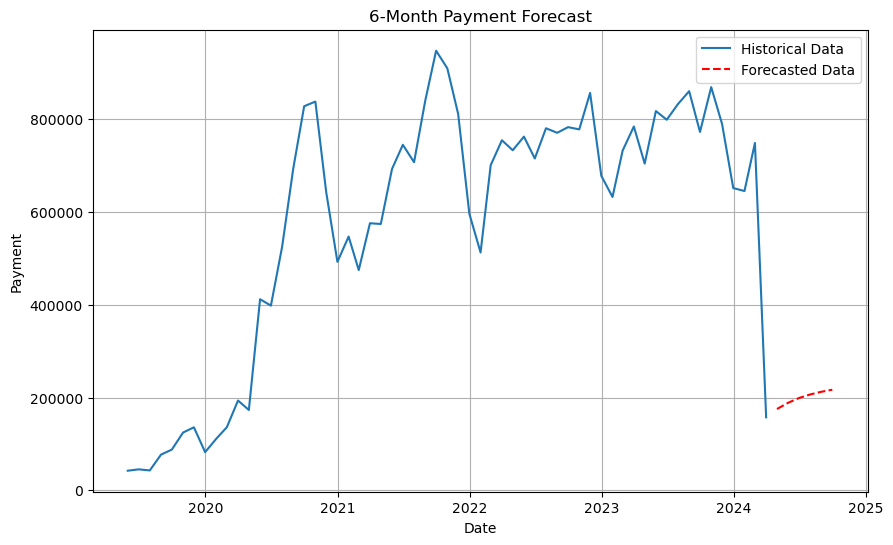

In [26]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
import matplotlib.pyplot as plt

# Sample monthly payments data (for demonstration)
import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')
data = {
    'date_paid': df['date_paid'],
    'payment': df['total']}

# Create a DataFrame
df = pd.DataFrame(data)

# Convert 'date_paid' to datetime format
df['date_paid'] = pd.to_datetime(df['date_paid'])

# Step 1: Aggregate the data by month (sum payments for each month)
# If your data is already aggregated by month, you can skip this step
df.set_index('date_paid', inplace=True)
monthly_payments = df.resample('M').sum()

# Step 2: Fit the ARIMA model
# Define the ARIMA model (p, d, q)
model = ARIMA(monthly_payments['payment'], order=(1, 1, 1))
model_fit = model.fit()

# Step 3: Forecast the next 6 months
forecast_steps = 6  # Number of months to forecast
forecast = model_fit.forecast(steps=forecast_steps)

# Generate dates for the forecasted period
forecast_dates = pd.date_range(start=monthly_payments.index[-1], periods=forecast_steps+1, freq='M')[1:]

# Step 4: Create a new DataFrame to hold the forecasted values
forecast_df = pd.DataFrame({
    'payment': forecast
}, index=forecast_dates)

# Step 5: Plot the historical and forecasted data
plt.figure(figsize=(10, 6))

# Plot historical data
plt.plot(monthly_payments.index, monthly_payments['payment'], label='Historical Data')

# Plot forecasted data
plt.plot(forecast_df.index, forecast_df['payment'], label='Forecasted Data', linestyle='--', color='red')

plt.title('6-Month Payment Forecast')
plt.xlabel('Date')
plt.ylabel('Payment')
plt.legend()
plt.grid(True)
plt.show()


Prediction of customer retention rate based on the first order.

In [27]:
# import pandas as pd
# Forecasting average customer lifetime value based on purchase history.
import re
# read bigquery data into pandas dataframe
import pandas as pd


df = pd.read_csv('dataprocesscompleted.csv')
# Load your dataset

# Convert the date to datetime format
df['date'] = pd.to_datetime(df['date_paid'])

# Step 1: Calculate Average Order Value (AOV) for each customer
aov_df = df.groupby('customer_id')['total'].mean().reset_index()
aov_df.columns = ['customer_id', 'avg_order_value']

# Step 2: Calculate Purchase Frequency (F) for each customer
purchase_counts = df.groupby('customer_id')['order_id'].count().reset_index()
purchase_counts.columns = ['customer_id', 'purchase_frequency']

# Step 3: Calculate Customer Lifespan (T) - typically calculated by observing the duration of a customer's activity
# For simplicity, we can use the difference between their first and last purchase as an approximation of their active lifespan
df['year'] = df['date'].dt.year
lifespan_df = df.groupby('customer_id').agg(first_purchase=('date', 'min'), last_purchase=('date', 'max')).reset_index()

# Calculate the number of years a customer has been active
lifespan_df['customer_lifespan'] = (lifespan_df['last_purchase'] - lifespan_df['first_purchase']).dt.days / 365
lifespan_df['customer_lifespan'] = lifespan_df['customer_lifespan'].apply(lambda x: max(1, x))  # At least 1 year

# Step 4: Merge AOV, purchase frequency, and customer lifespan
clv_df = pd.merge(aov_df, purchase_counts, on='customer_id')
clv_df = pd.merge(clv_df, lifespan_df[['customer_id', 'customer_lifespan']], on='customer_id')

# Step 5: Forecast CLV
clv_df['clv'] = clv_df['avg_order_value'] * clv_df['purchase_frequency'] * clv_df['customer_lifespan']

# Step 6: Preview the calculated CLV for each customer
print(clv_df[['customer_id', 'clv']].head())


   customer_id            clv
0            4    1400.000000
1            5   91561.852055
2            6   20112.413699
3            7    1310.000000
4            8  480534.273973


top products sales

In [28]:
import pandas as pd
import json
import matplotlib.pyplot as plt

# Step 1: 加载数据


# 查看数据的列名
print(df.columns)

# Step 2: 提取 'items' 列中的嵌套产品信息
def extract_items(item_json):
    try:
        item_data = json.loads(item_json) if isinstance(item_json, str) else item_json
        products = []
        for product in item_data.get('cart', []):  # 确保 'cart' 是列表
            if isinstance(product, dict):
                products.append({
                    'name': product.get('name', 'Unknown'),
                    'category': product.get('category', 'Unknown'),
                    'price': product.get('price', 0),
                    'quantity': 1  # 默认设为 1
                })
            else:
                print(f"Skipping non-dictionary product: {product}")
        return products
    except (TypeError, json.JSONDecodeError) as e:
        print(f"Error parsing items: {e}")
        return []

# 应用函数提取产品信息
df['products'] = df['items'].apply(extract_items)

# 将产品信息展开成多行
df_exploded = df.explode('products').reset_index(drop=True)

# 处理 'products' 列
df_products = pd.json_normalize(df_exploded['products'])
df_final = pd.concat([df_exploded, df_products], axis=1)

# 检查提取的产品名称和价格
print(df_final[['name', 'category', 'price']].head())

# Step 3: 计算 'total_price' (订单中所有产品的总金额)
df_final['total_price'] = df_final['price'] * df_final['quantity']

# Step 4: 分析高利润产品（最受欢迎产品）
df_product_sales = df_final.groupby('name')['total_price'].sum().reset_index()
df_product_sales = df_product_sales.sort_values(by='total_price', ascending=False)

# 输出前10个产品的销售额
print("Top 10 Products by Sales:")
print(df_product_sales.head(10))
df_product_sales.to_csv('top_10_products_sales.csv', index=False)

print("Top 10 product sales data saved to 'top_10_products_sales.csv'.")

Index(['order_id', 'customer_id', 'ip_addr', 'date_created', 'date_paid',
       'total', 'status', 'items', 'date', 'year'],
      dtype='object')
Skipping non-dictionary product: 0
Skipping non-dictionary product: 2
Skipping non-dictionary product: 1
Skipping non-dictionary product: 2
Skipping non-dictionary product: 0
Skipping non-dictionary product: 2
Skipping non-dictionary product: 3
Skipping non-dictionary product: 4
Skipping non-dictionary product: 5
Skipping non-dictionary product: 6
Skipping non-dictionary product: 0
Skipping non-dictionary product: 1
Skipping non-dictionary product: 2
Skipping non-dictionary product: 4
Skipping non-dictionary product: 5
Skipping non-dictionary product: 6
Skipping non-dictionary product: 0
Skipping non-dictionary product: 1
Skipping non-dictionary product: 2
Skipping non-dictionary product: 3
Skipping non-dictionary product: 5
Skipping non-dictionary product: 6
Skipping non-dictionary product: 7
Skipping non-dictionary product: 8
Skipping non

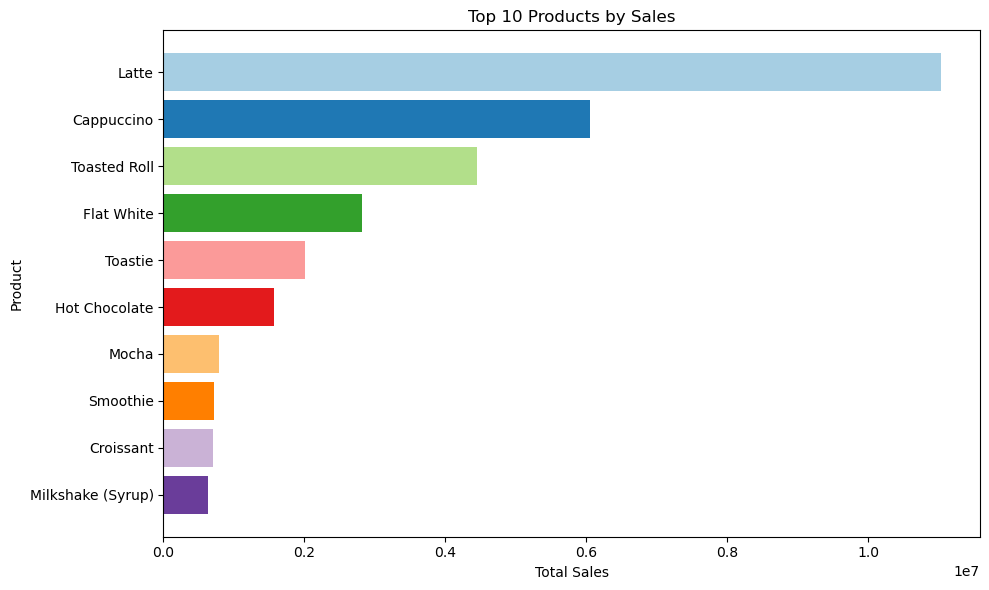

In [29]:
import matplotlib.pyplot as plt

# 可视化前10个产品的销售额，并为每个产品使用不同的颜色
colors = plt.cm.Paired(range(10))  # 使用 Paired 调色板生成10种颜色

plt.figure(figsize=(10,6))
plt.barh(df_product_sales['name'].head(10), df_product_sales['total_price'].head(10), color=colors)
plt.title('Top 10 Products by Sales')
plt.xlabel('Total Sales')
plt.ylabel('Product')
plt.gca().invert_yaxis()  # 反转 y 轴，使排名最高的产品位于图的顶部
plt.tight_layout()
plt.show()


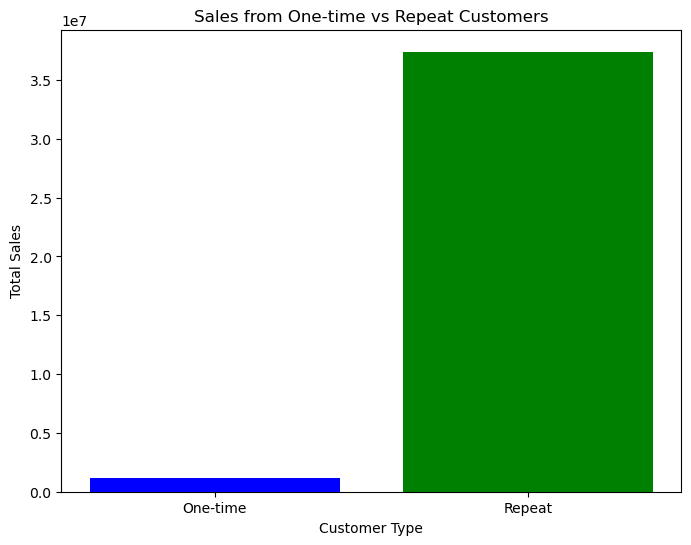

In [30]:
# Step 5: 顾客忠诚度分析
# 假设 df 包含 customer_id，使用 customer_id 来分析顾客行为
df_customer_orders = df.groupby('customer_id')['order_id'].nunique().reset_index()
df_customer_orders.columns = ['customer_id', 'total_orders']

# 将客户分为一次性客户和重复客户
df_customer_orders['customer_type'] = df_customer_orders['total_orders'].apply(lambda x: 'Repeat' if x > 1 else 'One-time')

# 计算每类客户的总销售额
df_customer_type_sales = df_final.merge(df_customer_orders[['customer_id', 'customer_type']], on='customer_id')
df_customer_type_sales = df_customer_type_sales.groupby('customer_type')['total_price'].sum().reset_index()

# 绘制一次性客户与重复客户的销售额对比
plt.figure(figsize=(8,6))
plt.bar(df_customer_type_sales['customer_type'], df_customer_type_sales['total_price'], color=['blue', 'green'])
plt.title('Sales from One-time vs Repeat Customers')
plt.xlabel('Customer Type')
plt.ylabel('Total Sales')
plt.show()

we find we should focus on old customer because old customer give us a large amount of orders

In [31]:
# Step 6: 订单总金额和产品销售的关系分析
# 根据 'order_id' 计算每个订单中的产品总金额
df_order_total = df_final.groupby('order_id')['total_price'].sum().reset_index()

# 输出前10个订单的总金额
print("Top 10 Orders by Total Amount:")
print(df_order_total.sort_values(by='total_price', ascending=False).head(10))


Top 10 Orders by Total Amount:
       order_id  total_price
21309     25393      13500.0
32386     36891      11890.0
25442     29633      11320.0
34817     39399      10450.0
30896     35228      10200.0
26002     30238       9950.0
24789     28962       9950.0
24590     28760       9950.0
28953     33241       9750.0
29375     33671       9750.0


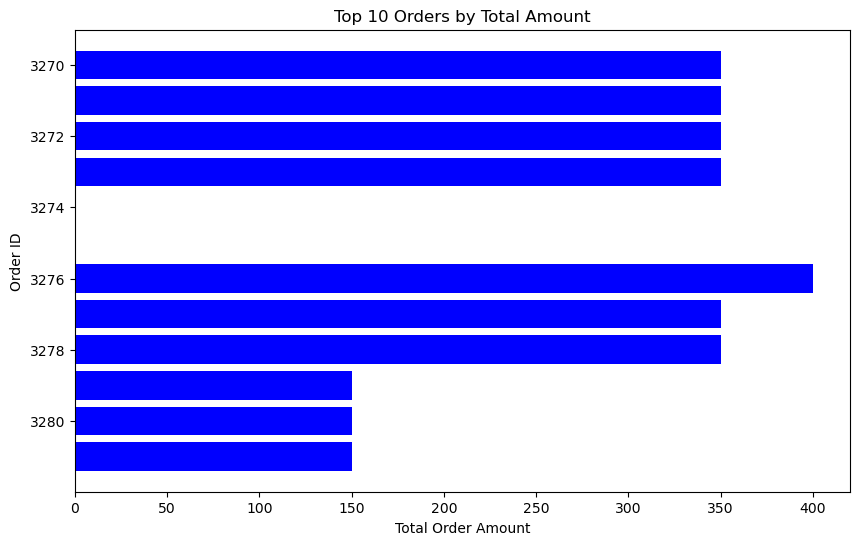

In [32]:
# 可视化前10个订单的总金额
plt.figure(figsize=(10,6))
plt.barh(df_order_total['order_id'].head(10), df_order_total['total_price'].head(10), color='blue')
plt.title('Top 10 Orders by Total Amount')
plt.xlabel('Total Order Amount')
plt.ylabel('Order ID')
plt.gca().invert_yaxis()
plt.show()


very important customer

In [33]:
# 2	Strategies to improve customer retention at the cafe.
import pandas as pd

# Sample customer data
 

# Aggregating the data to get customer-level insights (total spend and number of orders)
customer_stats = df.groupby('customer_id').agg(
    total_spent=('total', 'sum'),
    num_orders=('order_id', 'count')
).reset_index()

# Classify customers based on their total spending and number of orders
def classify_customer(row):
    if row['num_orders'] > 2 and row['total_spent'] > 500:
        return 'VIP'
    elif row['num_orders'] > 1:
        return 'Regular'
    else:
        return 'Occasional'

customer_stats['segment'] = customer_stats.apply(classify_customer, axis=1)

# Display the segmented customers
print(customer_stats)
# VIP表示花费超过500的人，值得重点发展维护客户关系

      customer_id  total_spent  num_orders     segment
0               4       1400.0           4         VIP
1               5      43916.0          60         VIP
2               6       4727.0           3         VIP
3               7       1310.0           1  Occasional
4               8     127190.0         156         VIP
...           ...          ...         ...         ...
1591         1753        480.0           1  Occasional
1592         1754        530.0           1  Occasional
1593         1756        480.0           1  Occasional
1594         1757        480.0           1  Occasional
1595         1758       1030.0           1  Occasional

[1596 rows x 4 columns]


In [34]:
customer_stats

,customer_id,total_spent,num_orders,segment
0,4,1400.0,4,VIP
1,5,43916.0,60,VIP
2,6,4727.0,3,VIP
3,7,1310.0,1,Occasional
4,8,127190.0,156,VIP
...,...,...,...,...
1591,1753,480.0,1,Occasional
1592,1754,530.0,1,Occasional
1593,1756,480.0,1,Occasional
1594,1757,480.0,1,Occasional


In [35]:
import seaborn as sns

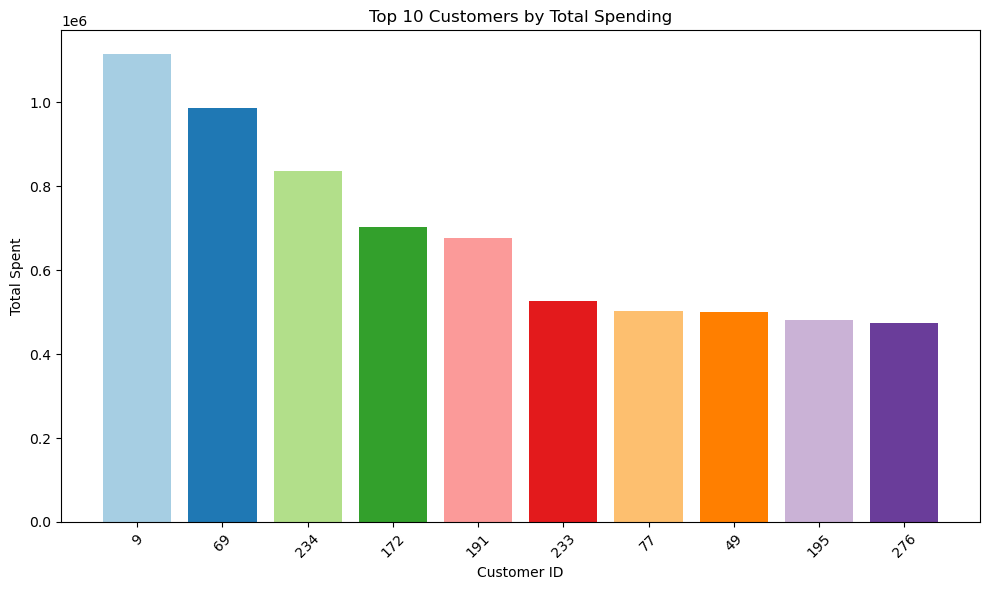

In [36]:
import pandas as pd
import matplotlib.pyplot as plt


# 获取 total_spent 排名前十的顾客
top_10_customers = customer_stats.nlargest(10, 'total_spent')

# 可视化：用不同颜色显示前十名顾客的消费金额
plt.figure(figsize=(10, 6))
plt.bar(top_10_customers['customer_id'].astype(str), top_10_customers['total_spent'], color=plt.cm.Paired(range(10)))
plt.xlabel('Customer ID')
plt.ylabel('Total Spent')
plt.title('Top 10 Customers by Total Spending')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [37]:
# loyalty
# Track customer visits and create a simple loyalty program

# Define a function that checks if a customer qualifies for a reward based on order count
def check_loyalty_rewards(customer_id, df):
    customer_orders = df[df['customer_id'] == customer_id]
    if len(customer_orders) >= 5:
        return f'Customer {customer_id} qualifies for a reward!'
    else:
        return f'Customer {customer_id} needs {5 - len(customer_orders)} more orders for a reward.'

# Apply loyalty program for each customer
for customer_id in df['customer_id'].unique():
    result = check_loyalty_rewards(customer_id, df)
    print(result)


Customer 517 qualifies for a reward!
Customer 519 qualifies for a reward!
Customer 776 qualifies for a reward!
Customer 9 qualifies for a reward!
Customer 1290 qualifies for a reward!
Customer 12 qualifies for a reward!
Customer 782 qualifies for a reward!
Customer 20 qualifies for a reward!
Customer 276 qualifies for a reward!
Customer 791 qualifies for a reward!
Customer 29 qualifies for a reward!
Customer 541 qualifies for a reward!
Customer 543 qualifies for a reward!
Customer 32 qualifies for a reward!
Customer 1569 qualifies for a reward!
Customer 806 needs 2 more orders for a reward.
Customer 1064 qualifies for a reward!
Customer 44 qualifies for a reward!
Customer 305 qualifies for a reward!
Customer 313 qualifies for a reward!
Customer 324 qualifies for a reward!
Customer 69 qualifies for a reward!
Customer 77 qualifies for a reward!
Customer 846 qualifies for a reward!
Customer 847 qualifies for a reward!
Customer 92 qualifies for a reward!
Customer 1640 qualifies for a rewar

In [38]:
# Define a loyalty program for customers
def loyalty_program(customer_id, df):
    customer_orders = df[df['customer_id'] == customer_id]
    if len(customer_orders) >= 5:
        return f'Customer {customer_id} qualifies for a loyalty reward!'
    else:
        remaining_orders = 5 - len(customer_orders)
        return f'Customer {customer_id} needs {remaining_orders} more orders to qualify for a reward.'

# Apply loyalty program for each customer
for customer_id in df['customer_id'].unique():
    print(loyalty_program(customer_id, df))


Customer 517 qualifies for a loyalty reward!
Customer 519 qualifies for a loyalty reward!
Customer 776 qualifies for a loyalty reward!
Customer 9 qualifies for a loyalty reward!
Customer 1290 qualifies for a loyalty reward!
Customer 12 qualifies for a loyalty reward!
Customer 782 qualifies for a loyalty reward!
Customer 20 qualifies for a loyalty reward!
Customer 276 qualifies for a loyalty reward!
Customer 791 qualifies for a loyalty reward!
Customer 29 qualifies for a loyalty reward!
Customer 541 qualifies for a loyalty reward!
Customer 543 qualifies for a loyalty reward!
Customer 32 qualifies for a loyalty reward!
Customer 1569 qualifies for a loyalty reward!
Customer 806 needs 2 more orders to qualify for a reward.
Customer 1064 qualifies for a loyalty reward!
Customer 44 qualifies for a loyalty reward!
Customer 305 qualifies for a loyalty reward!
Customer 313 qualifies for a loyalty reward!
Customer 324 qualifies for a loyalty reward!
Customer 69 qualifies for a loyalty reward!
Cu

In [39]:
import pandas as pd

# Sample customer data


# Aggregate data for customer segmentation
customer_segment = df.groupby('customer_id')['total'].agg(total_spent='sum', num_orders='count').reset_index()

# Define customer segments based on spend and frequency
def segment_customer(row):
    if row['total_spent'] > 500 and row['num_orders'] > 2:
        return 'High-Value Customer'
    elif row['total_spent'] > 200:
        return 'Regular Customer'
    else:
        return 'Occasional Customer'

# Apply segmentation
customer_segment['segment'] = customer_segment.apply(segment_customer, axis=1)

# Display customer segments
print(customer_segment)


      customer_id  total_spent  num_orders              segment
0               4       1400.0           4  High-Value Customer
1               5      43916.0          60  High-Value Customer
2               6       4727.0           3  High-Value Customer
3               7       1310.0           1     Regular Customer
4               8     127190.0         156  High-Value Customer
...           ...          ...         ...                  ...
1591         1753        480.0           1     Regular Customer
1592         1754        530.0           1     Regular Customer
1593         1756        480.0           1     Regular Customer
1594         1757        480.0           1     Regular Customer
1595         1758       1030.0           1     Regular Customer

[1596 rows x 4 columns]


In [40]:
# Suggest upselling based on previous customer purchases
def upsell_cross_sell(customer_id, df):
    customer_data = df[df['customer_id'] == customer_id]
    last_order_price = customer_data['total'].iloc[-1]
    
    if last_order_price < 200:
        return f'Suggest customer {customer_id} a combo deal for next visit to increase order value.'
    elif last_order_price >= 200:
        return f'Encourage customer {customer_id} to try premium items for a more exclusive experience.'
    
# Apply upsell suggestions
for customer_id in df['customer_id'].unique():
    print(upsell_cross_sell(customer_id, df))


Encourage customer 517 to try premium items for a more exclusive experience.
Encourage customer 519 to try premium items for a more exclusive experience.
Encourage customer 776 to try premium items for a more exclusive experience.
Encourage customer 9 to try premium items for a more exclusive experience.
Encourage customer 1290 to try premium items for a more exclusive experience.
Encourage customer 12 to try premium items for a more exclusive experience.
Encourage customer 782 to try premium items for a more exclusive experience.
Encourage customer 20 to try premium items for a more exclusive experience.
Encourage customer 276 to try premium items for a more exclusive experience.
Encourage customer 791 to try premium items for a more exclusive experience.
Encourage customer 29 to try premium items for a more exclusive experience.
Encourage customer 541 to try premium items for a more exclusive experience.
Encourage customer 543 to try premium items for a more exclusive experience.
Enc

best day time to sale cafe

In [41]:
import pandas as pd

# Sample transaction data with 'date_paid' having a full timestamp

df['date_paid'] = pd.to_datetime(df['date_paid'])

# Extract the hour and day of the week from 'date_paid'
df['hour'] = df['date_paid'].dt.hour
df['day_of_week'] = df['date_paid'].dt.day_name()

# Group by day of the week and hour to count the number of transactions
transactions_by_time = df.groupby(['day_of_week', 'hour'])['order_id'].count().reset_index()

# Sort the days of the week in chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
transactions_by_time['day_of_week'] = pd.Categorical(transactions_by_time['day_of_week'], categories=days_order, ordered=True)
transactions_by_time = transactions_by_time.sort_values(['day_of_week', 'hour']).reset_index(drop=True)

# Display the transactions by hour and day of the week
print(transactions_by_time)


    day_of_week  hour  order_id
0        Monday     4         1
1        Monday     5        33
2        Monday     6       701
3        Monday     7      1143
4        Monday     8      1040
..          ...   ...       ...
118      Sunday    19         3
119      Sunday    20         1
120      Sunday    21        12
121      Sunday    22         6
122      Sunday    23         1

[123 rows x 3 columns]


In [42]:
import pandas as pd

# Sample transaction data with 'date_paid' having a full timestamp, 'total' as the transaction amount, and 'order_id'

df['date_paid'] = pd.to_datetime(df['date_paid'])

# Extract the hour and day of the week from 'date_paid'
df['hour'] = df['date_paid'].dt.hour
df['day_of_week'] = df['date_paid'].dt.day_name()

# Group by day of the week and hour to sum the total transaction amount for each time period
transactions_by_time = df.groupby(['day_of_week', 'hour'])['total'].sum().reset_index()

# Sort the days of the week in chronological order
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
transactions_by_time['day_of_week'] = pd.Categorical(transactions_by_time['day_of_week'], categories=days_order, ordered=True)
transactions_by_time = transactions_by_time.sort_values(['day_of_week', 'hour']).reset_index(drop=True)

# Sort by the total transaction amount in descending order to get the top 5 best time slots
top_5_best_times = transactions_by_time.sort_values(by='total', ascending=False).head(5)

# Display the top 5 best times to open the cafe based on total transaction amount
print(top_5_best_times)


    day_of_week  hour      total
94     Saturday     9  1352098.0
80       Friday     8  1321904.0
93     Saturday     8  1310546.0
109      Sunday     9  1198842.0
62     Thursday     8  1181845.0


we find on saturday 9 am and friday 8 am is the best day time to sale our cafe.

online sales trend by years and months

In [43]:
df = pd.read_csv(r'C:\Users\YU244\output.csv')

# 将 'date_paid' 转换为日期格式
df['date_paid'] = pd.to_datetime(df['date_paid'])
df_revenue = df[
    ['order_id', 'customer_id', 'total', 'date_paid']
].drop_duplicates().reset_index(drop=True)
df_revenue['order_year'] = (
    df_revenue['date_paid'].dt.year
)
df_revenue['order_month'] = (
    df_revenue['date_paid'].dt.month
)
df_revenue['order_day'] = (
    df_revenue['date_paid'].dt.day
)
df_revenue['order_dow'] = (
    df_revenue['date_paid'].dt.dayofweek
)
df_revenue['order_hour'] = (
    df_revenue['date_paid'].dt.hour
)
df_revenue['FY'] = (
    df_revenue.apply(
        lambda x: 'FY' + str(x['order_year'])[-2:] if x['order_month'] < 7
        else 'FY' + str(x['order_year'] + 1)[-2:],
        axis=1,
    )
)
monthly = (
    df_revenue[
        ['order_year', 'order_month', 'total']
    ].groupby(['order_year', 'order_month']).sum()
    .reset_index(drop=False)
)


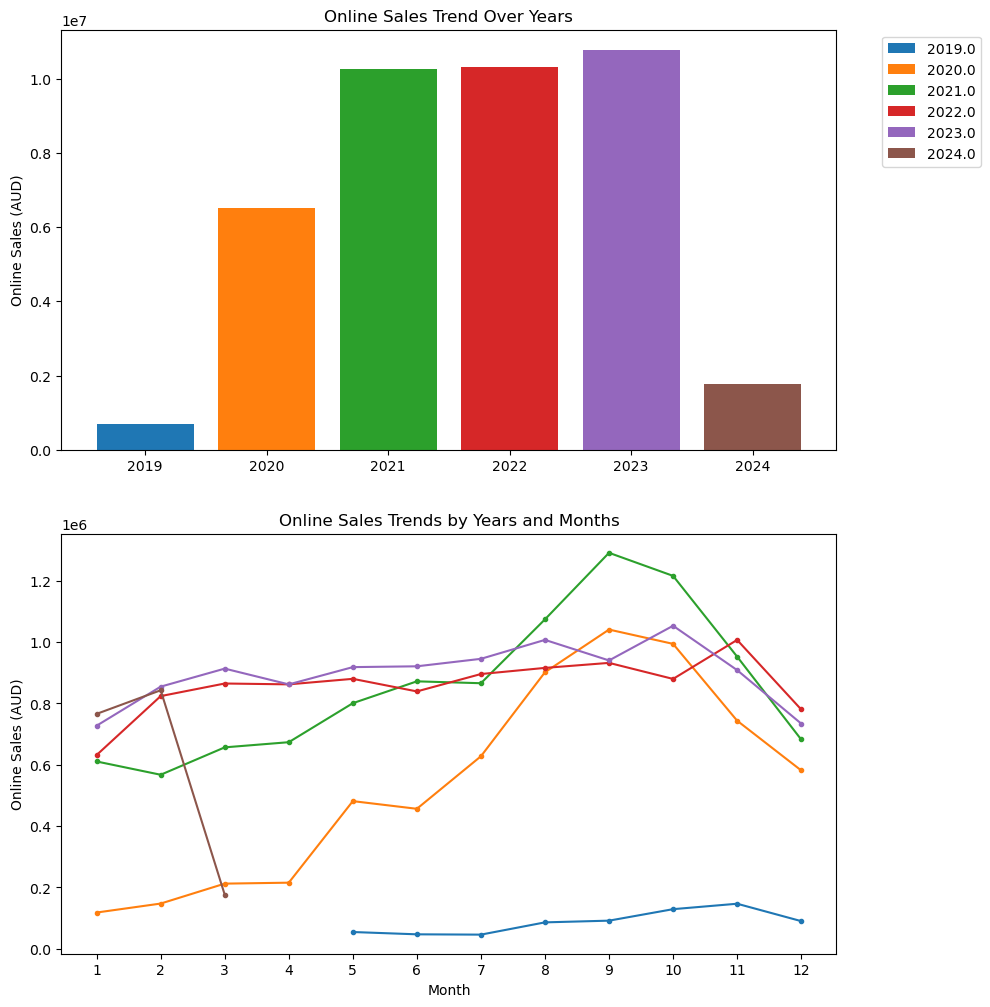

In [44]:
# Plot monthly revenue trend
fig, axes = plt.subplots(nrows=2, figsize=(10, 12))

for year in sorted(monthly['order_year'].unique()):
    month_data = monthly[
        monthly['order_year'] == year
    ]
    Y = month_data['total']
    X = month_data['order_month']
    
    axes[1].plot(X, Y, label=year, marker='.')
    axes[0].bar(
        x=year,
        height=month_data['total'].sum(), 
        label=year,
    )

axes[0].set_title('Online Sales Trend Over Years')
axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1))
axes[0].set_xlabel('')
axes[0].set_ylabel('Online Sales (AUD)')
axes[1].set_title('Online Sales Trends by Years and Months')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Online Sales (AUD)')
axes[1].set_xticks(range(1, 13, 1))
plt.show()

Pearson Correlation Coefficients

In [45]:
import json
import pandas as pd

# 读取 CSV 文件，确保路径正确
df = pd.read_csv(r'C:\Users\YU244\output.csv')

# 假设 df['items'] 包含 JSON 字符串，提取产品名称、单价、customer_id、date_paid、order_id、口味和销售额
product_list = []

for index, row in df.iterrows():
    try:
        # 将 'items' 列中的值转换为字符串，然后加载为字典
        order_data = json.loads(str(row['items']))
        products = order_data.get('cart', [])
        
        # 确保 products 是一个列表
        if isinstance(products, list):
            # 遍历产品，提取 'name'、'price'、'customer_id'、'date_paid' 和 'order_id'
            for product in products:
                # 确保 product 是一个字典
                if isinstance(product, dict):
                    product_name = product.get('name', 'Unknown')
                    base_price = product.get('price', 0) / 100  # 假设价格以分为单位
                    customer_id = row['customer_id']  # 提取 customer_id
                    date_paid = row['date_paid']  # 提取 date_paid
                    order_id = row['order_id']  # 提取 order_id

                    # 提取口味及其额外价格
                    options = product.get('options', [])
                    flavor_list = []
                    option_price = 0  # 累积所有选项的价格
                    
                    for option in options:
                        option_name = option.get('name', 'Unknown')
                        option_value = option.get('value', 'Unknown')
                        option_price += option.get('price', 0) / 100  # 假设价格以分为单位
                        # 将每个口味的 name 和 value 作为“口味”
                        flavor_list.append(f"{option_name}: {option_value}")
                    
                    # 计算总销售额（基础价格 + 选项价格）
                    total_price_calculated = base_price + option_price

                    # 添加到产品列表，并保留来自原始数据的 total 列
                    product_list.append({
                        'name': product_name,
                        'base_price': base_price,
                        'total_price_calculated': total_price_calculated,  # 计算的总销售额
                        'total': row['total'],  # 保留原始的 total 列
                        'flavors': ', '.join(flavor_list),  # 口味组合
                        'customer_id': customer_id,
                        'date_paid': date_paid,
                        'order_id': order_id
                    })
    except (json.JSONDecodeError, TypeError):
        print(f"Error decoding JSON for row {index}")

# 将提取的数据转换为 DataFrame
product_df = pd.DataFrame(product_list)

# 检查拆分后的 DataFrame，保留了两个总销售额列
print(product_df.head())

# 保存结果到 CSV 文件
product_df.to_csv('processed_product_with_total.csv', index=False)

print("结果已保存到 'processed_product_with_total.csv' 文件中")


Error decoding JSON for row 21861
         name  base_price  total_price_calculated  total  \
0       Latte         4.8                     9.6   1280   
1     Toastie         8.0                    16.0   1280   
2  Flat White         6.4                    12.8   1280   
3       Latte         6.4                    12.8   1280   
4  Cappuccino         6.4                    12.8   1280   

                                             flavors  customer_id  \
0  size: LRG, Milk: Soy, Strength: Full, Decaf: N...          517   
1          size: BACON-EGG-CHEESE, Bread: Multigrain          517   
2  size: XLG, Milk: Lactose Free, Strength: Full,...          519   
3  size: XLG, Milk: Lactose Free, Strength: Full,...          519   
4  size: XLG, Milk: Oat Milk, Strength: Full, Dec...          519   

             date_paid  order_id  
0  2021-04-14 05:56:37     11787  
1  2021-04-14 05:56:37     11787  
2  2024-03-05 10:17:23     40606  
3  2024-03-05 10:17:23     40606  
4  2024-03-01 1

In [46]:
import pandas as pd
import json

# 假设 'product_df' 已经从 JSON 文件中生成
# 读取 CSV 文件并生成数据集
df = pd.read_csv(r'C:\Users\YU244\output.csv')

# 提取相关数据处理代码略，假设我们已经生成了 'product_df'

# 1. 计算每个 'name' 的总销售额
name_sales = product_df.groupby('name')['total'].sum().reset_index()

# 2. 计算每个 'name' 的总销售额占比
name_sales['total_percentage'] = (name_sales['total'] / name_sales['total'].sum()) * 100

# 3. 提取占比前 10 的 'name'
top_10_names = name_sales.nlargest(10, 'total_percentage')['name']

# 4. 过滤原始数据，只保留前 10 个 'name'
product_df_top_10 = product_df[product_df['name'].isin(top_10_names)]

# 5. 对 'name' 列进行独热编码
product_df_encoded = pd.get_dummies(product_df_top_10, columns=['name'], drop_first=False)

# 6. 选择数值型列进行相关性分析（包括独热编码后的 'name' 列）
numeric_columns = product_df_encoded.select_dtypes(include=['float64', 'int64', 'uint8']).columns.tolist()

# 7. 计算皮尔逊相关系数矩阵
correlation_matrix = product_df_encoded[numeric_columns].corr(method='pearson')

# 8. 打印相关性矩阵
print("Pearson Correlation Matrix:")
print(correlation_matrix)

# 9. 保存处理后的 DataFrame
product_df_encoded.to_csv('processed_product_top10_with_onehot.csv', index=False)

print("结果已保存到 'processed_product_top10_with_onehot.csv' 文件中")


Pearson Correlation Matrix:
                        base_price  total_price_calculated     total  \
base_price                1.000000                0.981110  0.313553   
total_price_calculated    0.981110                1.000000  0.314764   
total                     0.313553                0.314764  1.000000   
customer_id               0.101884                0.090452  0.091303   
order_id                  0.142367                0.129792 -0.034915   

                        customer_id  order_id  
base_price                 0.101884  0.142367  
total_price_calculated     0.090452  0.129792  
total                      0.091303 -0.034915  
customer_id                1.000000  0.467999  
order_id                   0.467999  1.000000  
结果已保存到 'processed_product_top10_with_onehot.csv' 文件中


In [47]:
#检查one-hot code是否成功
# 检查独热编码后的列
print("Encoded columns:", product_df_encoded.columns)


Encoded columns: Index(['base_price', 'total_price_calculated', 'total', 'flavors',
       'customer_id', 'date_paid', 'order_id', 'name_Babychino',
       'name_Cappuccino', 'name_Croissant', 'name_Flat White',
       'name_Hot Chocolate', 'name_Latte', 'name_Milkshake (Syrup)',
       'name_Muffin', 'name_Toasted Roll', 'name_Toastie'],
      dtype='object')


All columns: ['base_price', 'total_price_calculated', 'total', 'flavors', 'customer_id', 'date_paid', 'order_id', 'name_Babychino', 'name_Cappuccino', 'name_Croissant', 'name_Flat White', 'name_Hot Chocolate', 'name_Latte', 'name_Milkshake (Syrup)', 'name_Muffin', 'name_Toasted Roll', 'name_Toastie']
Name columns (one-hot encoded): ['name_Babychino', 'name_Cappuccino', 'name_Croissant', 'name_Flat White', 'name_Hot Chocolate', 'name_Latte', 'name_Milkshake (Syrup)', 'name_Muffin', 'name_Toasted Roll', 'name_Toastie']
Columns used for correlation analysis:
['base_price', 'total_price_calculated', 'total', 'customer_id', 'order_id', 'name_Babychino', 'name_Cappuccino', 'name_Croissant', 'name_Flat White', 'name_Hot Chocolate', 'name_Latte', 'name_Milkshake (Syrup)', 'name_Muffin', 'name_Toasted Roll', 'name_Toastie']
Pearson Correlation Matrix:
                        base_price  total_price_calculated     total  \
base_price                1.000000                0.981110  0.313553   
t

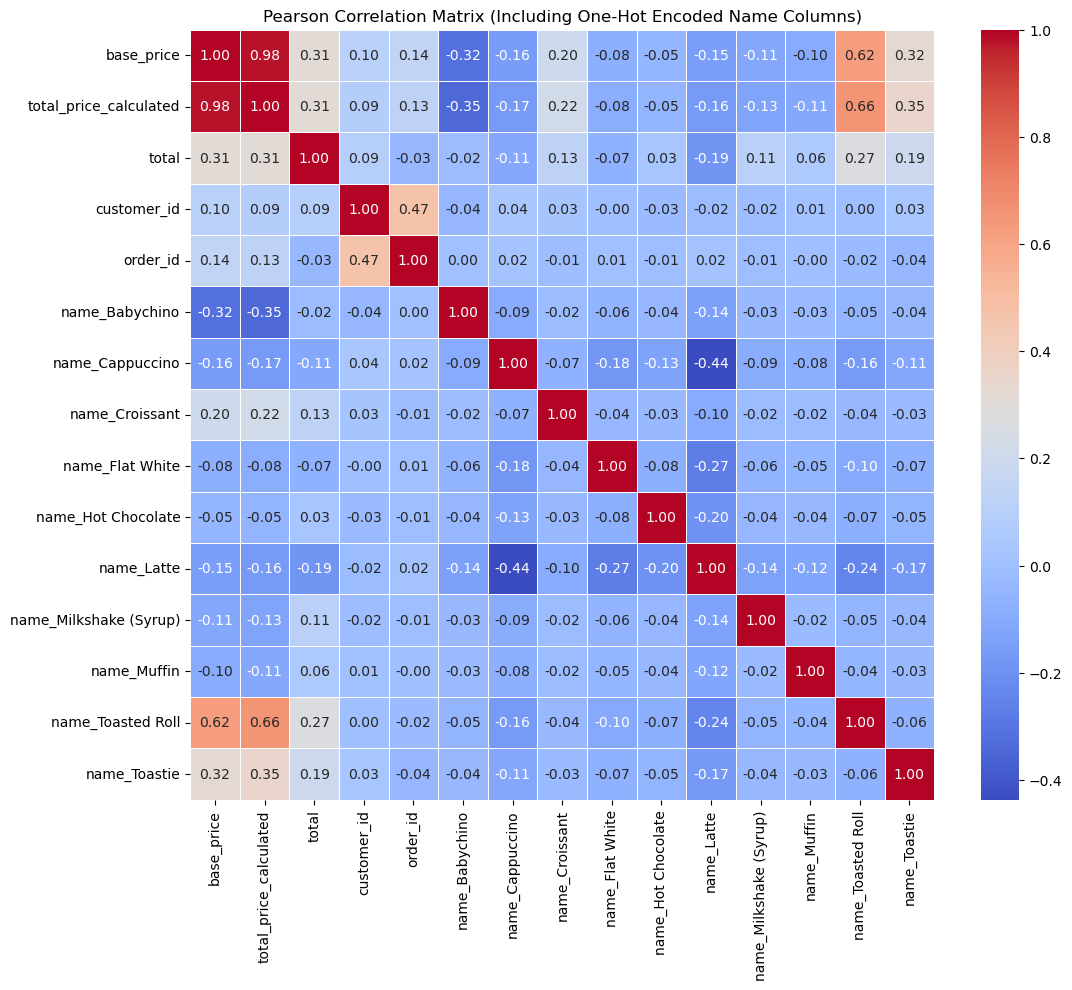

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设 'product_df_encoded' 已经生成，包括独热编码的列

# 1. 检查独热编码后的列
print("All columns:", product_df_encoded.columns.tolist())

# 2. 手动筛选出以 'name_' 开头的独热编码列
name_columns = [col for col in product_df_encoded.columns if col.startswith('name_')]
print(f"Name columns (one-hot encoded): {name_columns}")

# 3. 合并数值型列和 'name_' 开头的独热编码列
numeric_columns = product_df_encoded.select_dtypes(include=['float64', 'int64', 'uint8']).columns.tolist()
numeric_columns += name_columns  # 手动添加 'name_' 独热编码列

# 4. 打印用于相关性分析的列，确认 'name_' 列被包含
print("Columns used for correlation analysis:")
print(numeric_columns)

# 5. 计算皮尔逊相关系数矩阵
correlation_matrix = product_df_encoded[numeric_columns].corr(method='pearson')

# 6. 打印相关性矩阵
print("Pearson Correlation Matrix:")
print(correlation_matrix)

# 7. 绘制相关性矩阵热力图
plt.figure(figsize=(12, 10))  # 设置图像尺寸
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Matrix (Including One-Hot Encoded Name Columns)')
plt.show()


#### Discuss Insights:
Correlation between products（top ten） and total order amount:

Positively correlated products: such as name_Toasted Roll and name_Toastie, these products may be common choices for some customers when purchasing high-value orders, so you can infer that they contribute positively to the total order amount.
Negatively correlated products: such as name_Babychino and name_Latte, these products tend to have lower total order amounts when purchased, which may mean that they are usually associated with small orders or they are low-priced.
Product combination sales strategy:

If certain products have a high positive correlation with total, you can consider highlighting these products in your sales strategy or bundling these products with other high-priced items during promotion.
Negatively correlated products, such as name_Babychino, may be cheaper products that are suitable for promotion to price-sensitive customers or combination with other products to increase order amounts.
Summary:
Positively correlated products may contribute more to the total order amount and are worth further promotion or bundling with other high-priced products.
Negatively correlated products may be associated with small orders and may be suitable for pairing with other products to increase the total order amount.
Weakly correlated products do not have a significant linear relationship with the total order amount, but can be promoted in other ways (such as discounts or promotions).

#correlation between date and sales

Columns used for correlation analysis:
['year', 'month', 'day', 'weekday', 'quarter', 'total', 'base_price', 'total_price_calculated']
Pearson Correlation Matrix for date features:
                            year     month       day   weekday   quarter  \
year                    1.000000 -0.285982 -0.017633 -0.010449 -0.277313   
month                  -0.285982  1.000000 -0.061492  0.000020  0.970985   
day                    -0.017633 -0.061492  1.000000 -0.006066 -0.039820   
weekday                -0.010449  0.000020 -0.006066  1.000000  0.004872   
quarter                -0.277313  0.970985 -0.039820  0.004872  1.000000   
total                  -0.047910  0.020078 -0.004620  0.206368  0.020013   
base_price              0.086642  0.005661  0.003086  0.051959  0.006913   
total_price_calculated  0.071992  0.007388  0.004735  0.053386  0.008533   

                           total  base_price  total_price_calculated  
year                   -0.047910    0.086642                0.0

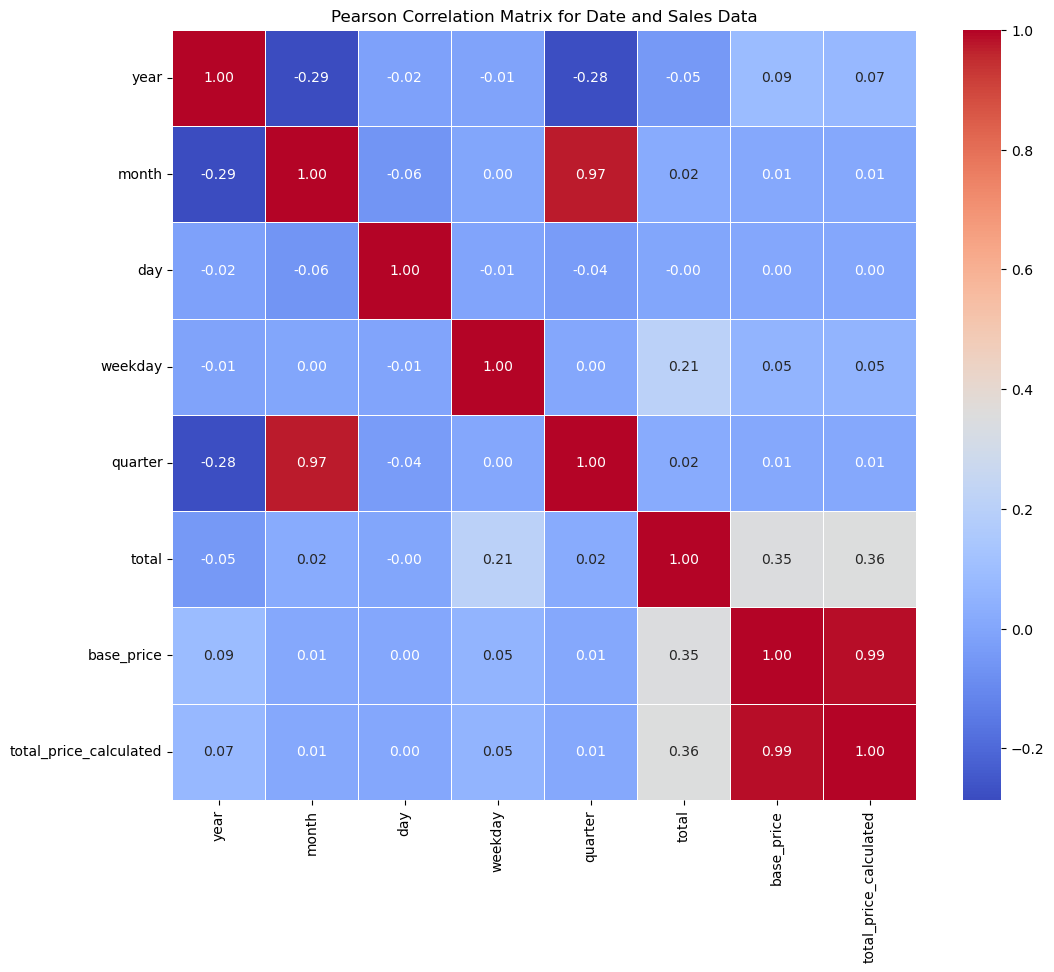

In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取 CSV 文件
df = pd.read_csv(r'C:\Users\YU244\processed_product_with_total.csv')
product_df = df.copy()

# 确保 'date_paid' 列是日期格式
product_df['date_paid'] = pd.to_datetime(product_df['date_paid'], errors='coerce')

# 1. 提取日期特征，例如 年份、月份、星期几、季度 等
product_df['year'] = product_df['date_paid'].dt.year
product_df['month'] = product_df['date_paid'].dt.month
product_df['day'] = product_df['date_paid'].dt.day
product_df['weekday'] = product_df['date_paid'].dt.weekday  # Monday=0, Sunday=6
product_df['quarter'] = product_df['date_paid'].dt.quarter

# 2. 选择提取的日期特征和其他数值型列进行相关性分析
numeric_columns = ['year', 'month', 'day', 'weekday', 'quarter', 'total', 'base_price', 'total_price_calculated']

# 打印用于相关性分析的列
print("Columns used for correlation analysis:")
print(numeric_columns)

# 3. 计算皮尔逊相关系数矩阵
correlation_matrix = product_df[numeric_columns].corr(method='pearson')

# 4. 打印相关性矩阵
print("Pearson Correlation Matrix for date features:")
print(correlation_matrix)

# 5. 绘制相关性矩阵热力图
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Pearson Correlation Matrix for Date and Sales Data')
plt.show()


#### Discuss Insights:
weekday has a correlation of 0.206 with total:

This is a relatively high positive correlation, indicating that some weekdays or weekends may have some impact on total sales.
You can further explore which day (weekday or weekend) contributes more to sales. By further grouping weekday (such as weekday and weekend), you can find sales patterns more clearly.
Other date features have low correlations with total:

month, day, year, and quarter have very low correlations with total (close to 0), which shows that these date features do not show a clear linear relationship. In other words, they have no significant impact on total sales from the perspective of month, day, quarter, etc.
base_price and total_price_calculated also have low correlations with date:

Similar to total, base_price and total_price_calculated also have low correlations with date features, indicating that there is no clear trend in the change of pricing and sales over time.

#explore the relationship between weekdays and sales

In [50]:
import pandas as pd

# 导入 CSV 文件为 DataFrame
df = pd.read_csv('dataprocesscompleted.csv')

# 显示前几行数据，以确认导入是否正确
df.head()


,order_id,customer_id,ip_addr,date_created,date_paid,total,status,items
0,11787,517,81741da2cc0e5207bfefbb4ec257b2393d5e13a0,2021-04-14 05:56:06,2021-04-14 05:56:37,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
1,40606,519,ccf5e36bddfbce1a7de2c04874190a057b30588d,2024-03-05 10:16:40,2024-03-05 10:17:23,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
2,40488,519,ccf5e36bddfbce1a7de2c04874190a057b30588d,2024-03-01 11:40:20,2024-03-01 11:40:58,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
3,38252,519,1f8e636af94847a55418d2c03ccf4b1601d10512,2023-12-05 08:48:02,2023-12-05 08:49:24,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."
4,13470,776,d4c84c8e50cf80cc385d669000208e59e304fcca,2021-06-20 12:10:17,2021-06-20 12:11:09,1280.0,2,"{""cart_size"":2,""cart_surcharge"":0,""cart_total_..."


Average sales for weekday and weekend:
is_weekend
0    1438.165054
1    1902.334218
Name: total, dtype: float64
Average sales for each weekday (0=Monday, 6=Sunday):
weekday
0.0    1289.166159
1.0    1324.055518
2.0    1278.365197
3.0    1352.998916
4.0    1620.097535
5.0    1778.125152
6.0    2031.471326
Name: total, dtype: float64


C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\459263736.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Weekday', 'Weekend'], y=weekday_sales.values, palette='Blues')  # 使用蓝色调色板


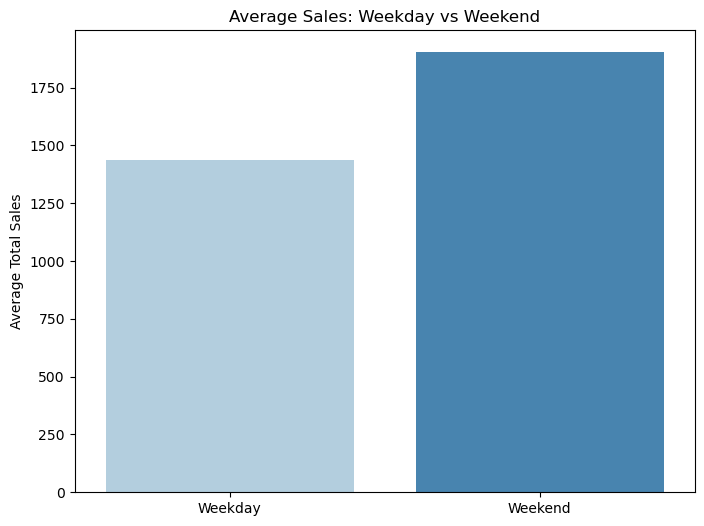

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\459263736.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'],


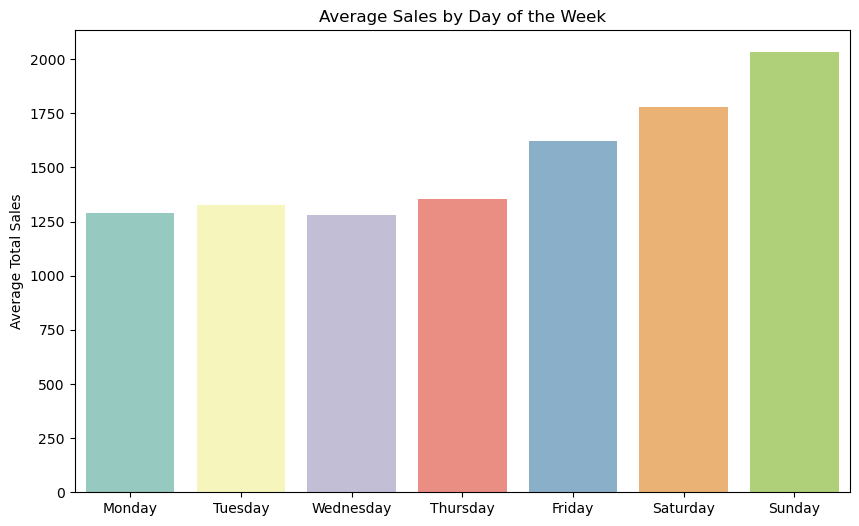

In [51]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 将 weekday 分为工作日（0-4）和周末（5-6）
product_df['is_weekend'] = product_df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# 2. 分析工作日和周末的平均销售额
weekday_sales = product_df.groupby('is_weekend')['total'].mean()

# 打印工作日和周末的平均销售额
print("Average sales for weekday and weekend:")
print(weekday_sales)

# 3. 分析每个工作日的平均销售额
daily_sales = product_df.groupby('weekday')['total'].mean()

# 打印每个工作日的平均销售额
print("Average sales for each weekday (0=Monday, 6=Sunday):")
print(daily_sales)

# 4. 可视化工作日与周末的平均销售额，使用不同的颜色
plt.figure(figsize=(8, 6))
sns.barplot(x=['Weekday', 'Weekend'], y=weekday_sales.values, palette='Blues')  # 使用蓝色调色板
plt.title('Average Sales: Weekday vs Weekend')
plt.ylabel('Average Total Sales')
plt.show()

# 5. 可视化每个工作日的平均销售额，使用不同的颜色
plt.figure(figsize=(10, 6))
sns.barplot(x=['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'], 
            y=daily_sales.values, palette='Set3')  # 使用Set3调色板
plt.title('Average Sales by Day of the Week')
plt.ylabel('Average Total Sales')
plt.show()



C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\2383508865.py:24: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', palette='coolwarm')


Average sales by hour (Friday and Weekend):
hour
0.0     1050.000000
1.0     2705.000000
5.0     1195.825243
6.0     1303.409509
7.0     1470.523017
8.0     1782.119141
9.0     1807.929046
10.0    1926.854490
11.0    2086.522398
12.0    2307.955847
13.0    2185.992879
14.0    1771.752066
15.0    1529.421488
16.0     622.500000
17.0     342.000000
19.0    1834.545455
20.0     860.000000
21.0    1235.600000
22.0     971.428571
23.0    3124.000000
Name: total, dtype: float64


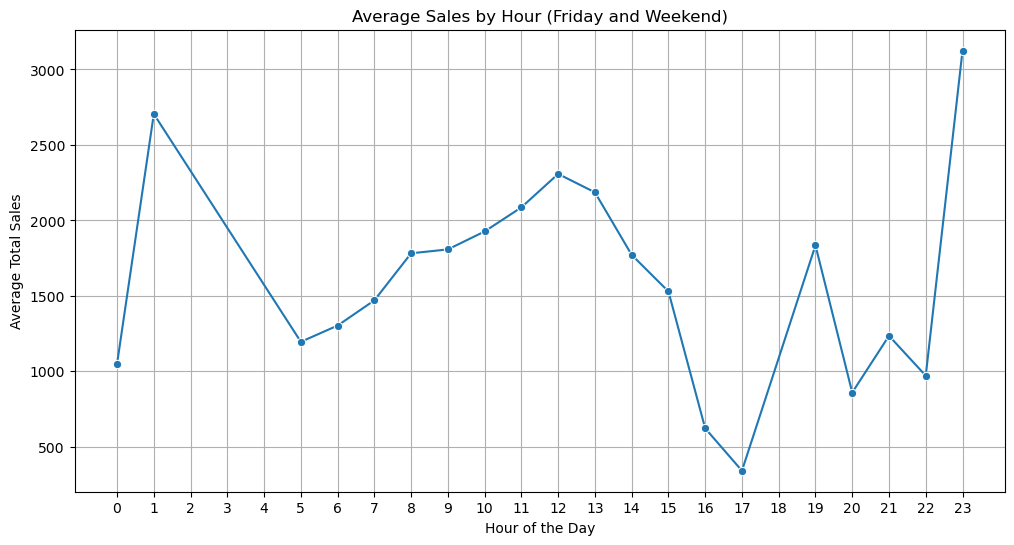

In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设 'product_df' 已经包含 'date_paid' 是日期格式
# 如果 'date_paid' 还不是日期格式，确保转换为日期格式
product_df['date_paid'] = pd.to_datetime(product_df['date_paid'], errors='coerce')

# 1. 提取小时特征
product_df['hour'] = product_df['date_paid'].dt.hour

# 2. 只选择周五（weekday=4）和周末（weekday=5和6）的数据
weekend_sales = product_df[product_df['weekday'].isin([4, 5, 6])]

# 3. 计算每小时的平均销售额
hourly_sales = weekend_sales.groupby('hour')['total'].mean()

# 打印每小时的平均销售额
print("Average sales by hour (Friday and Weekend):")
print(hourly_sales)

# 4. 可视化每小时的销售额
plt.figure(figsize=(12, 6))
sns.lineplot(x=hourly_sales.index, y=hourly_sales.values, marker='o', palette='coolwarm')
plt.title('Average Sales by Hour (Friday and Weekend)')
plt.xlabel('Hour of the Day')
plt.ylabel('Average Total Sales')
plt.xticks(range(0, 24))  # 设置 x 轴刻度为 0 到 23
plt.grid(True)
plt.show()


#insights: 
1. Sales during Early Morning Hours (Midnight to 1 AM)
There is a notable increase in sales around 12 AM and 1 AM, with 1 AM peaking at 2705.
Reasonable Explanation: This suggests that a segment of consumers, particularly on Fridays and weekends, may be staying up late or engaging in social activities and then ordering coffee or snacks online. This behavior is common in urban areas where nightlife is vibrant, especially among younger demographics. In Australia, where coffee culture is strong, even late-night consumption may be linked to coffee or related beverages to sustain energy during social events.
2. Morning to Midday Sales Peak
Sales begin to rise sharply around 5 AM, peaking between 8 AM and 12 PM, with the highest value at 12 PM (2307).
Reasonable Explanation: The morning to midday time frame is typically the prime period for coffee consumption. This aligns with consumer routines, where people start their day with coffee, either on their way to work or during breakfast. In Australia, coffee plays a significant role in daily life, and morning coffee runs are ingrained in both work culture and leisure routines, particularly on weekends when people may relax or meet friends for brunch.
3. Afternoon Decline, Evening Surge
Sales gradually decline from 1 PM to 4 PM, but there is a noticeable rebound in the evening, particularly at 7 PM and 11 PM, with 11 PM reaching a significant peak of 3124.
Reasonable Explanation: The drop in sales during the afternoon likely reflects the end of the lunch period, as people shift to other activities. However, the evening surge, especially around 7 PM and 11 PM, indicates that consumers may be engaging in social activities like dining out or attending events, and are ordering coffee or snacks later in the evening. This behavior could also suggest post-dinner consumption or preparation for a night out. In urban Australian cities, evening online coffee orders might be fulfilling late-night cravings or providing an energy boost before or after social events.
Summary and Recommendations:
Key Sales Hours: The morning peak between 8 AM and 12 PM represents a crucial sales period, both online and offline. Optimizing promotions and ensuring product availability during this window is essential.
Potential of the Night Market: The late-night sales spikes at 1 AM and 11 PM reveal strong demand for coffee or snacks during these hours. Targeted promotions for the evening and night-time crowd, perhaps offering special discounts or late-night exclusive menus, could drive further sales in this time frame.
Managing Sales Fluctuations: By understanding these peak periods, you can better align inventory and operational strategies. Ensuring supply during morning and late-night spikes will help capture and capitalize on demand.

Holidays and Special Events :Australia has many public holidays and special events (such as Christmas, Easter, Australia Day, etc.)

Average sales during near holidays and non-holidays:
is_near_holiday
0    1586.669425
1    1633.601093
Name: total, dtype: float64


C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\642632289.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Non-Holiday Period', 'Near Holiday Period'], y=near_holiday_sales.values, palette='Set2')


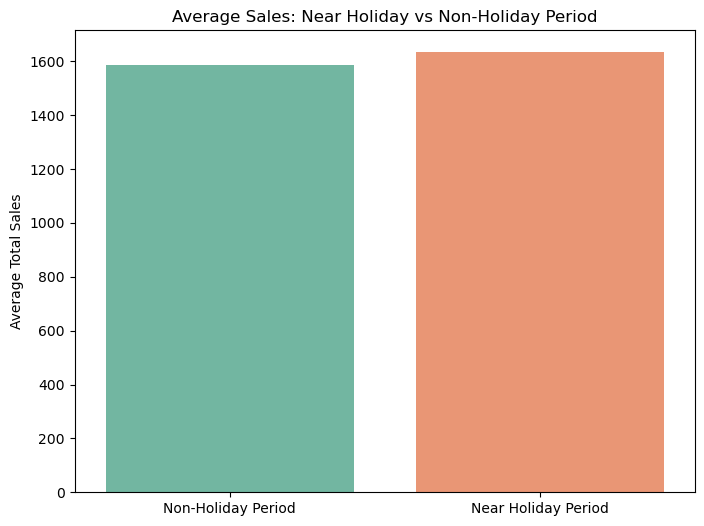

Correlation between near holiday periods and total sales:
                 is_near_holiday     total
is_near_holiday         1.000000  0.002084
total                   0.002084  1.000000


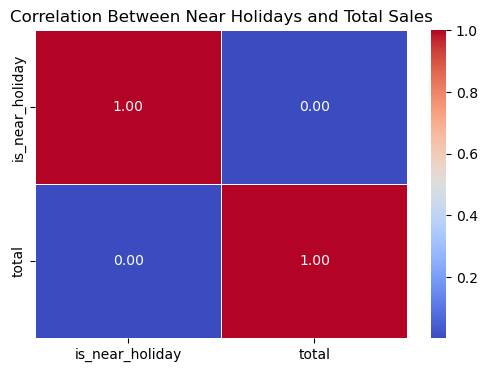

In [53]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 读取数据集
df = pd.read_csv(r'C:\Users\YU244\processed_product_with_total.csv')
product_df = df.copy()

# 确保 'date_paid' 是日期格式
product_df['date_paid'] = pd.to_datetime(product_df['date_paid'], errors='coerce')

# 1. 定义节假日列表（带年份）
# 这里使用 2024 年作为基准，但你可以根据不同年份调整
holidays = [
    pd.Timestamp('2024-01-01'),  # New Year's Day
    pd.Timestamp('2024-01-26'),  # Australia Day
    pd.Timestamp('2024-04-25'),  # Anzac Day
    pd.Timestamp('2024-12-25'),  # Christmas Day
    pd.Timestamp('2024-12-26'),  # Boxing Day
]

# 2. 标记节假日前后 3 天
def is_near_holiday(date, holidays, days=3):
    for holiday in holidays:
        if abs((date - holiday).days) <= days:  # 计算日期差并检查是否在前后 3 天
            return 1
    return 0

# 应用函数来标记节假日前后 3 天
product_df['is_near_holiday'] = product_df['date_paid'].apply(lambda x: is_near_holiday(x, holidays))

# 3. 计算节假日前后 3 天与非节假日的销售额
near_holiday_sales = product_df.groupby('is_near_holiday')['total'].mean()

# 打印节假日前后与非节假日的平均销售额
print("Average sales during near holidays and non-holidays:")
print(near_holiday_sales)

# 4. 可视化节假日前后销售额变化
plt.figure(figsize=(8, 6))
sns.barplot(x=['Non-Holiday Period', 'Near Holiday Period'], y=near_holiday_sales.values, palette='Set2')
plt.title('Average Sales: Near Holiday vs Non-Holiday Period')
plt.ylabel('Average Total Sales')
plt.show()

# 5. 计算节假日前后 3 天与销售额 'total' 的相关性
correlation = product_df[['is_near_holiday', 'total']].corr(method='pearson')

# 打印相关性结果
print("Correlation between near holiday periods and total sales:")
print(correlation)

# 6. 可视化相关性矩阵
plt.figure(figsize=(6, 4))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Between Near Holidays and Total Sales')
plt.show()


#insights:The correlation between is_near_holiday (whether the date is near a holiday) and total (sales) is 0.002, indicating a very weak positive correlation. Essentially, there is no significant linear relationship between sales and whether a date is near a holiday. This suggests that being near a holiday does not directly impact the total sales in a measurable way.

In [54]:
# Create a new dataframe for items with high churn risk
# Create a new dataframe for items with high retention probability
## Strategy Analysis: Removing High Churn Risk Items from Café Menu

Eliminate underperforming products

In [55]:
import pandas as pd

# 读取数据集
df = pd.read_csv(r'C:\Users\YU244\processed_product_with_total.csv')
product_df = df.copy()

# 假设数据集包含以下列: ['customer_id', 'order_id', 'product_id', 'total', 'date_paid']

# 1. 计算每个客户的购买次数
customer_purchase_counts = product_df.groupby('customer_id')['order_id'].nunique()

# 2. 标记新客户和老客户
# 新客户：只购买一次的客户
product_df['is_new_customer'] = product_df['customer_id'].map(lambda x: 1 if customer_purchase_counts[x] == 1 else 0)

# 老客户：购买超过三次的客户
product_df['is_loyal_customer'] = product_df['customer_id'].map(lambda x: 1 if customer_purchase_counts[x] > 7 else 0)

# 3. 识别表现不佳的产品
# 新客户购买一次后不再购买的产品
new_customer_bad_products = product_df[product_df['is_new_customer'] == 1].groupby('name')['order_id'].nunique()
new_customer_bad_products = new_customer_bad_products[new_customer_bad_products == 1].index

# 老客户购买某产品一次后不再购买的产品
loyal_customer_bad_products = product_df[product_df['is_loyal_customer'] == 1].groupby('name')['order_id'].nunique()
loyal_customer_bad_products = loyal_customer_bad_products[loyal_customer_bad_products == 1].index

# 4. 合并不良产品
bad_products = set(new_customer_bad_products).union(set(loyal_customer_bad_products))

# 5. 标记是否为不良产品
product_df['is_bad_product'] = product_df['name'].isin(bad_products).astype(int)

# 6. 计算不良产品与销售额 'total' 的相关性
correlation = product_df[['is_bad_product', 'total']].corr(method='pearson')

# 打印相关性结果
print("Correlation between bad products and total sales:")
print(correlation)

# 7. 剔除不良产品并重新计算总销售额
filtered_product_df = product_df[~product_df['is_bad_product'].astype(bool)]

# 计算剔除不良产品后的平均销售额
average_sales_after_removal = filtered_product_df['total'].mean()

# 打印剔除不良产品后的平均销售额
print("Average sales after removing bad products:", average_sales_after_removal)


Correlation between bad products and total sales:
                is_bad_product     total
is_bad_product        1.000000  0.018684
total                 0.018684  1.000000
Average sales after removing bad products: 1583.6004759993118


#insights: to Eliminate underperforming products by orders seems not work, we should use order frequency

#Eliminate underperforming products from order_frequency

In [56]:
# 计算每个产品的订单频率
product_order_frequency = product_df.groupby('name')['order_id'].nunique()

# 计算“坏产品”的订单频率
bad_product_frequency = product_order_frequency[product_order_frequency.index.isin(bad_products)]

# 打印“坏产品”的订单频率
print("Order frequency of bad products:")
print(bad_product_frequency)



Order frequency of bad products:
name
(Entree) Pasta                           15
Affogato                                  7
Carrot Cake                              17
Chicken & Mushroom Crepe                  4
Chips and Wedges                          7
Crepe                                     1
Date and Walnut Balls (GF,VG)           228
Eggs Benedict (V)                         1
Eggs Florentine (V)                       1
Espresso                                 16
Fish                                      1
Fried Chicken Sandwich                    1
Fruit Toast                              45
Fruit Toast (V)                           1
Kids Crepes                              17
Long Macchiato                           52
Omelette                                 45
Open Grilled Sandwich                    11
Piccolo                                 334
Risotto                                   1
Short Macchiato                           4
Spider                                

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\723572571.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='order_frequency', y='name', data=bad_product_frequency_df, palette=colors)


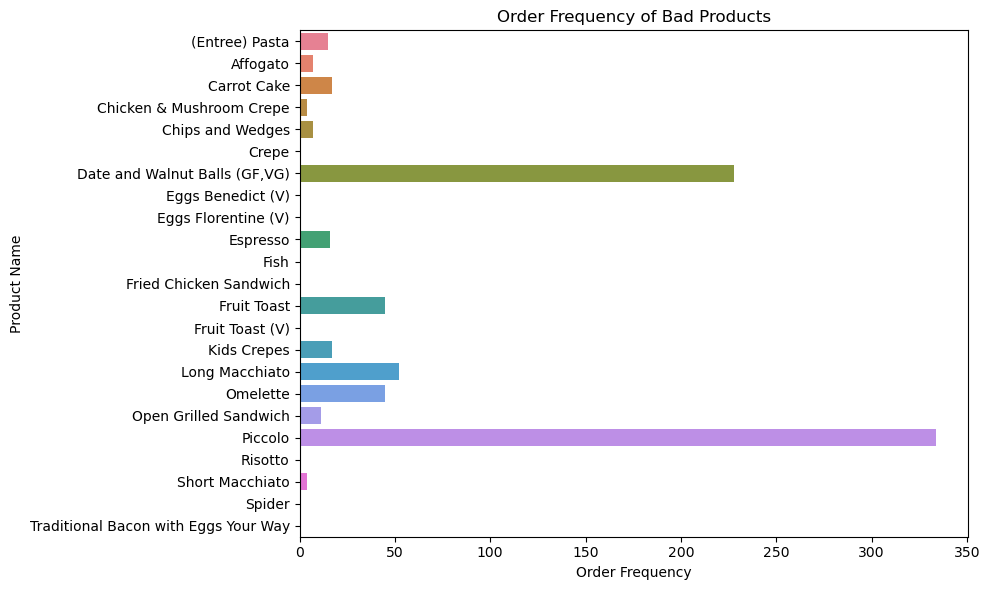

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 假设 'product_order_frequency' 和 'bad_product_frequency' 已经计算完成

# 将订单频率转为 DataFrame，便于可视化
bad_product_frequency_df = bad_product_frequency.reset_index()
bad_product_frequency_df.columns = ['name', 'order_frequency']

# 设置图像的大小
plt.figure(figsize=(10, 6))

# 使用 Seaborn 的 barplot 绘制条形图，并为每个条形设置不同的颜色
colors = sns.color_palette("husl", len(bad_product_frequency_df))  # 生成颜色

sns.barplot(x='order_frequency', y='name', data=bad_product_frequency_df, palette=colors)

# 设置图像标题和标签
plt.title("Order Frequency of Bad Products")
plt.xlabel("Order Frequency")
plt.ylabel("Product Name")

# 显示图像
plt.tight_layout()
plt.show()
# 保存“坏产品”订单频率数据为 CSV 文件
bad_product_frequency_df.to_csv('bad_product_frequency.csv', index=False)



validate if the product is bad

In [58]:
import pandas as pd
from scipy import stats

# Load dataset
df = pd.read_csv(r'C:\Users\YU244\processed_product_with_total.csv')
product_df = df.copy()

# Define the bad products with order frequency less than 20
order_frequency = {
    "(Entree) Pasta": 15,
    "Affogato": 7,
    "Carrot Cake": 17,
    "Chicken & Mushroom Crepe": 4,
    "Chips and Wedges": 7,
    "Crepe": 1,
    "Eggs Benedict (V)": 1,
    "Eggs Florentine (V)": 1,
    "Fish": 1,
    "Fried Chicken Sandwich": 1,
    "Fruit Toast (V)": 1,
    "Risotto": 1,
    "Short Macchiato": 4,
    "Spider": 1,
    "Traditional Bacon with Eggs Your Way": 1
}

# Filter out the bad products with order frequency less than 20
bad_products_list = [product for product, frequency in order_frequency.items() if frequency < 20]

# Mark whether the product is considered bad (order frequency < 20)
product_df['is_bad_product'] = product_df['name'].isin(bad_products_list).astype(int)

# Split the data into two groups: bad products and other products
bad_products_sales = product_df[product_df['is_bad_product'] == 1]['total']
other_products_sales = product_df[product_df['is_bad_product'] == 0]['total']

# Perform an independent t-test
t_stat, p_value = stats.ttest_ind(bad_products_sales, other_products_sales, equal_var=False)

# Print the results of the t-test
print(f"T-statistic: {t_stat}")
print(f"P-value: {p_value}")

# Interpretation
if p_value < 0.05:
    print("The test is significant: Bad products have statistically different sales compared to other products.")
else:
    print("The test is not significant: Bad products do not have statistically different sales compared to other products.")


T-statistic: 4.599413237979512
P-value: 1.865645019943295e-05
The test is significant: Bad products have statistically different sales compared to other products.


#Logistic Regression model Validation

In [59]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Load dataset
df = pd.read_csv(r'C:\Users\YU244\processed_product_with_total.csv')
product_df = df.copy()

# 创建目标变量 (is_bad_product)，并选择特征进行建模 (total)
product_df['is_bad_product'] = product_df['name'].isin(bad_products_list).astype(int)
X = product_df[['total']]  # 我们只使用 'total' 列进行预测，后续可添加其他特征
y = product_df['is_bad_product']

# 将数据分为训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 初始化逻辑回归模型
model = LogisticRegression()

# 训练模型
model.fit(X_train, y_train)

# 在测试集上进行预测
y_pred = model.predict(X_test)

# 输出结果：模型的准确率和混淆矩阵
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy * 100:.2f}%')

# 输出分类报告和混淆矩阵
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 99.89%
Confusion Matrix:
[[14102     0]
 [   16     0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     14102
           1       0.00      0.00      0.00        16

    accuracy                           1.00     14118
   macro avg       0.50      0.50      0.50     14118
weighted avg       1.00      1.00      1.00     14118



c:\ProgramData\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\ProgramData\Anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


We find the modle strongly support our insights to remove these bad products.The logistic regression model, validated through the sales data analysis, provides a statistically significant tool for identifying underperforming products. 

##ey Observations:
Low Order Frequency Products:

Many products, such as Crepe, Eggs Benedict (V), Risotto, and Spider, have only been ordered once. These are clear candidates for further review or potential removal from the menu, as their demand is extremely low.
Products like Fried Chicken Sandwich, Fish, and Traditional Bacon with Eggs Your Way also have very low order frequencies (1 order each), suggesting they might not resonate with your customer base.
Moderate Order Frequency Products:

Some products, like Affogato (7 orders) and Chips and Wedges (7 orders), have been ordered a few times but are still low-frequency compared to more popular items. These products might still have a niche market but may need a review to determine if they are worth keeping or improving.
Short Macchiato (4 orders) and Chicken & Mushroom Crepe (4 orders) also fall in this category, where they may not be frequent enough to justify their continued presence on the menu unless they have other redeeming qualities (e.g., high margins or seasonal popularity).
Higher Order Frequency Products:

Interestingly, some "bad products" still show relatively high order frequencies, such as Date and Walnut Balls (GF, VG) (228 orders) and Piccolo (334 orders). Despite their classification as "bad" based on customer retention behavior, these products are ordered frequently and may have specific customer appeal (e.g., dietary preferences like gluten-free or vegan for the Date and Walnut Balls). It's worth investigating why these frequent orders aren’t driving more repeat purchases from loyal customers.
Fruit Toast (45 orders) and Long Macchiato (52 orders) also show substantial demand and might need a deeper analysis into customer preferences or the reasons why they fail to generate repeat business from certain customers.


##Recommendations:
Consider Removing or Reworking Low-Frequency Products:

Products that have been ordered only once or twice (e.g., Crepe, Risotto, Spider, Eggs Florentine (V)) likely do not contribute significantly to overall sales or customer satisfaction. These items should either be removed from the menu or reworked to improve their appeal (e.g., through promotions, new ingredients, or recipe changes).
Analyze and Improve Moderate Frequency Products:

For items with moderate order frequency, such as Affogato and Chips and Wedges, a deeper look into customer feedback or product positioning might reveal opportunities to boost their popularity. You could consider adding special promotions or bundling these items with more popular menu choices to encourage higher sales.
Investigate Frequent Yet "Bad" Products:

Items like Date and Walnut Balls and Piccolo have high order frequencies but still fall into the "bad product" category based on customer retention analysis. These products likely cater to specific customer needs, such as dietary restrictions. It may be useful to reassess why loyal customers aren’t returning after purchasing these products. Perhaps improving customer experience, offering follow-up promotions, or refining product quality could convert occasional buyers into loyal customers.
Consider a Targeted Marketing Strategy:

For the higher-frequency products, especially those that cater to specific dietary needs, you might want to target niche markets more effectively. For example, promoting the Date and Walnut Balls (GF, VG) to vegan or gluten-free communities could further drive demand and customer loyalty.
Further Product Testing and Customer Feedback:

Before removing or significantly altering any product, it could be valuable to gather customer feedback or conduct A/B testing with alternative recipes or presentations to ensure that changes align with customer preferences.
Conclusion:
The products with very low order frequencies should be candidates for removal or reevaluation. Meanwhile, higher-frequency products classified as "bad" might need adjustments in marketing or customer experience to better retain customers. Focusing on the reasons behind customer retention and engagement with these products will help make informed decisions about which products to keep, improve, or eliminate.

Long Term Inventory Forecasting Exploration

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


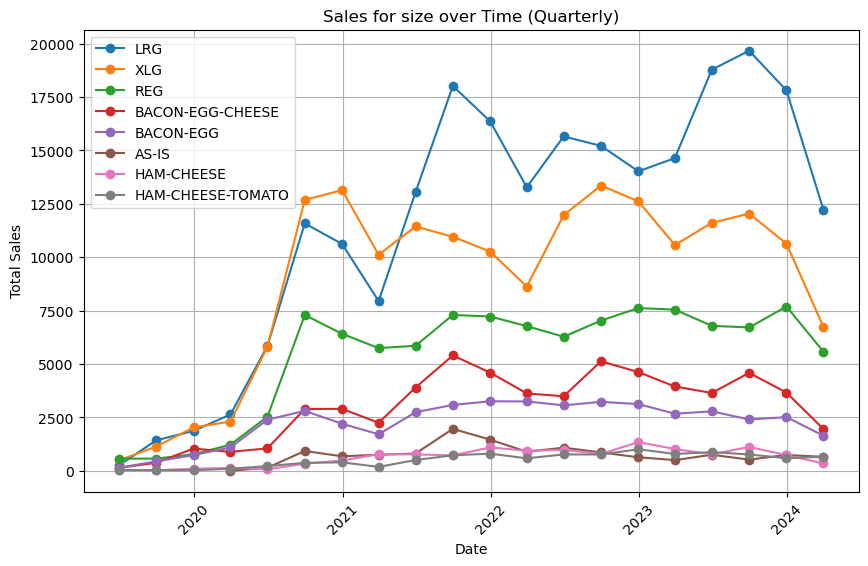

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


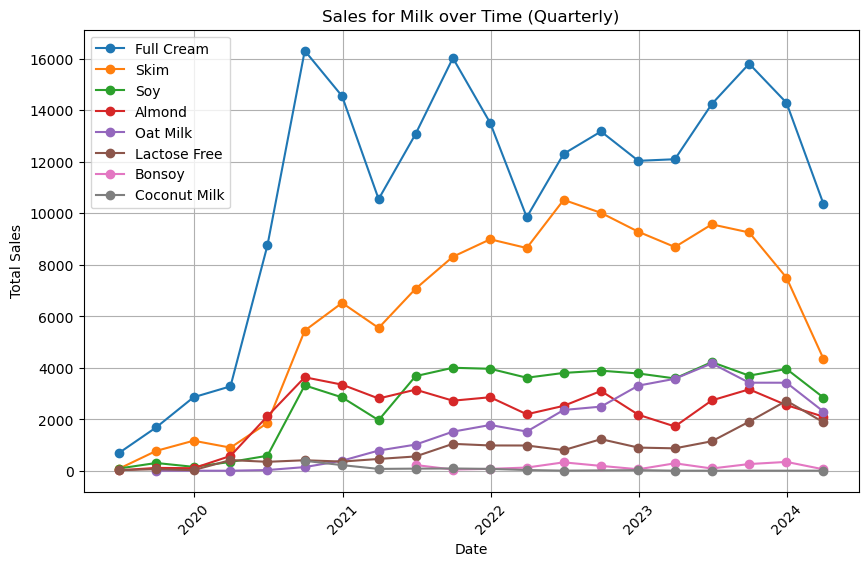

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


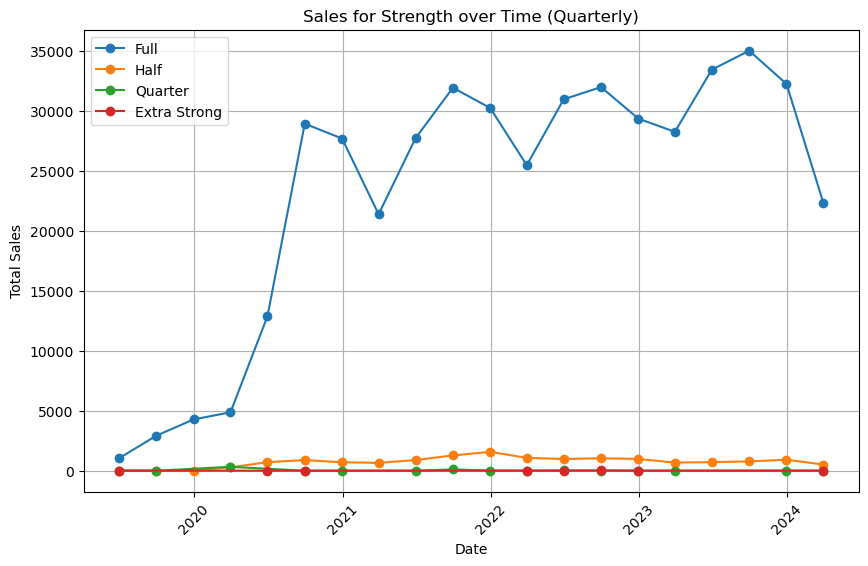

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


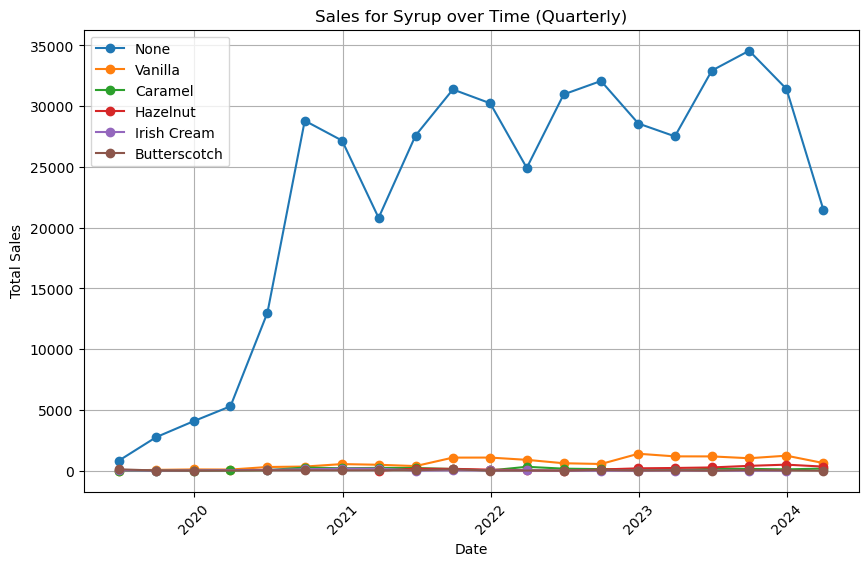

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


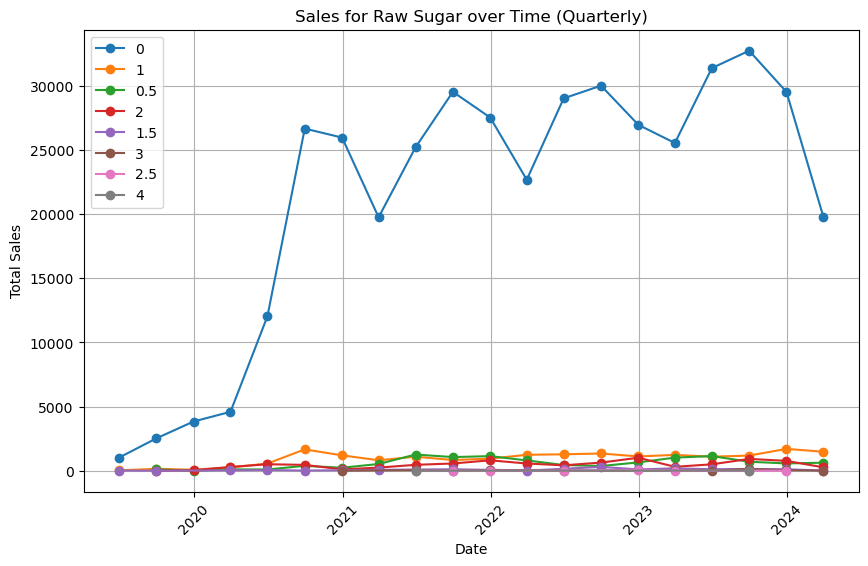

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


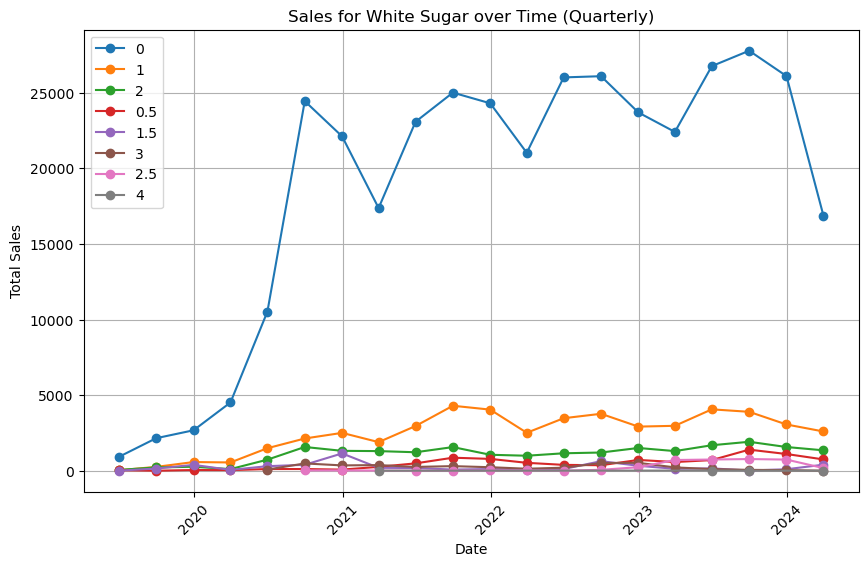

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


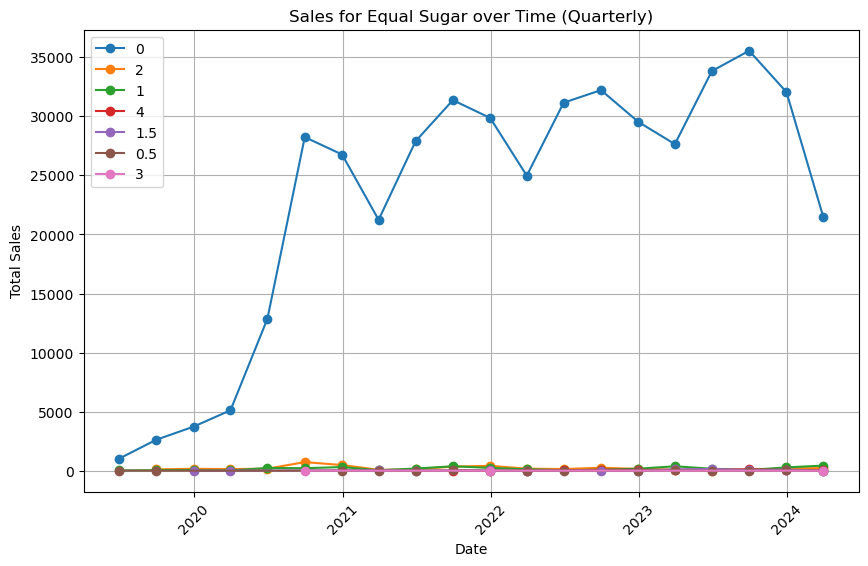

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


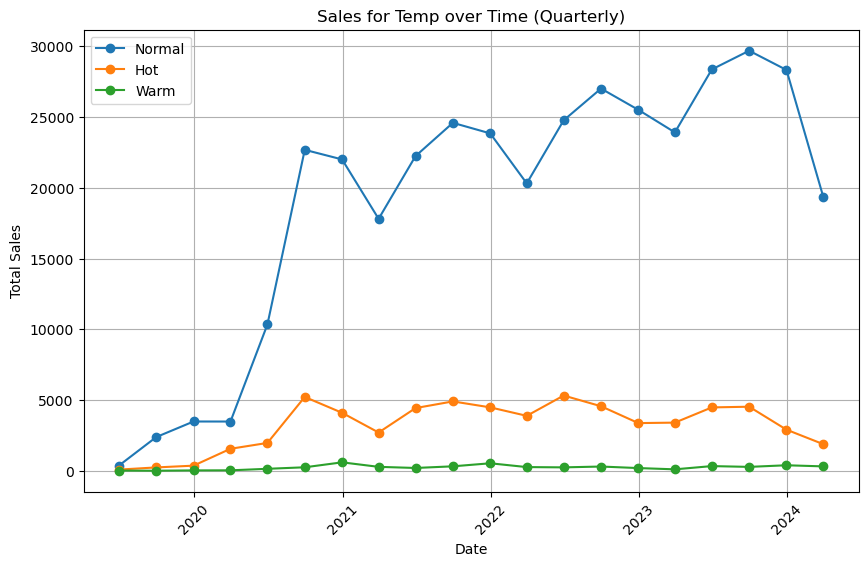

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


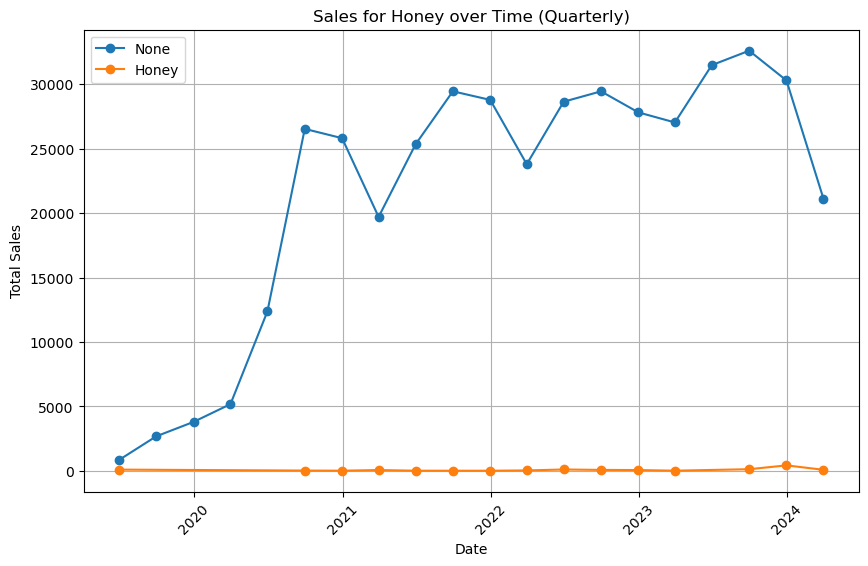

C:\Users\YU244\AppData\Local\Temp\ipykernel_14964\3731864836.py:43: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()


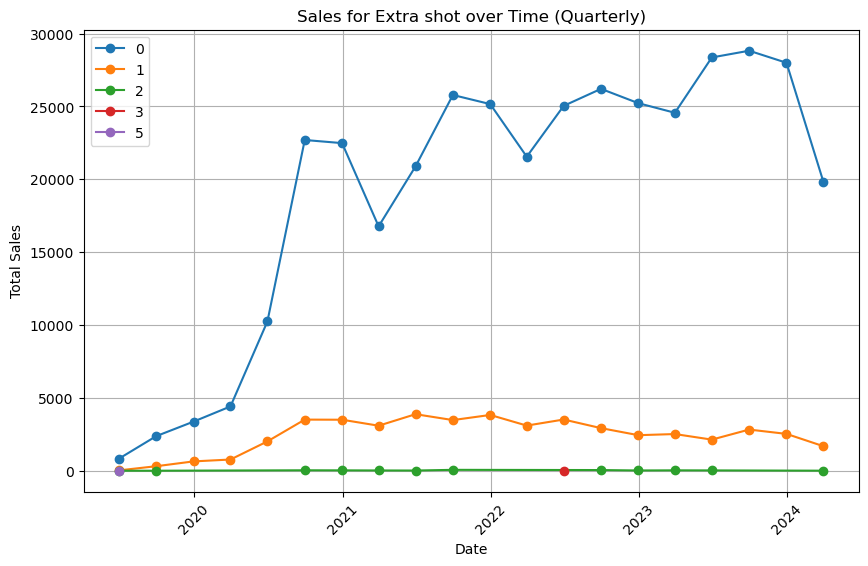

In [60]:
import pandas as pd
import matplotlib.pyplot as plt

# 假设 Product_Flavor_Analysis 数据已经加载到 df 中
df = pd.read_csv(r'C:\Users\YU244\Product_Flavor_Analysis.csv')

# 将 'date_paid' 转换为日期格式
df['date_paid'] = pd.to_datetime(df['date_paid'])

# 定义一个函数，将 'flavors' 列拆分为属性-值对的列表
def split_flavors(flavors_str):
    if pd.isnull(flavors_str):
        return []
    return [item.strip().split(': ', 1) for item in flavors_str.split(', ') if ': ' in item]

# 应用函数，将每个 'flavors' 拆分为属性-值对
df['flavor_pairs'] = df['flavors'].apply(split_flavors)

# 展开 'flavor_pairs' 列，使每个属性-值对成为一行
df_exploded = df.explode('flavor_pairs')

# 创建两个新列 'Flavor Type' 和 'Preference'，分别存放属性名称和对应值
df_exploded[['Flavor Type', 'Preference']] = pd.DataFrame(df_exploded['flavor_pairs'].tolist(), index=df_exploded.index)

# 删除不再需要的 'flavor_pairs' 列
df_exploded = df_exploded.drop(columns=['flavor_pairs'])

# 计算每个 Flavor Type 的总销售额，并选择前10个 Flavor Type
top_10_flavors = df_exploded.groupby('Flavor Type')['total_price'].sum().nlargest(10).index

# 只保留前10个 Flavor Type 的数据
df_top_flavors = df_exploded[df_exploded['Flavor Type'].isin(top_10_flavors)]

# 定义一个函数，绘制每个 Flavor Type 的销售趋势图，只显示前8个 Preference
def plot_flavor_sales(flavor_type, top_n_preferences=8):
    df_flavor = df_top_flavors[df_top_flavors['Flavor Type'] == flavor_type]

    # 按 Preference 汇总 total_price 并取前几个最重要的 Preference
    top_preferences = df_flavor.groupby('Preference')['total_price'].sum().nlargest(top_n_preferences).index
    df_flavor = df_flavor[df_flavor['Preference'].isin(top_preferences)]

    # 按季度汇总 total_price
    sales_by_quarter = df_flavor.groupby([pd.Grouper(key='date_paid', freq='Q'), 'Preference'])['total_price'].sum().reset_index()

    # 绘制时间序列图
    plt.figure(figsize=(10, 6))
    for preference in top_preferences:
        df_subset = sales_by_quarter[sales_by_quarter['Preference'] == preference]
        plt.plot(df_subset['date_paid'], df_subset['total_price'], marker='o', label=preference)

    plt.title(f'Sales for {flavor_type} over Time (Quarterly)')
    plt.xlabel('Date')
    plt.ylabel('Total Sales')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(True)
    plt.show()

# 为前10个 Flavor Type 绘制时间序列图，限制最多显示8个 Preference
for flavor_type in top_10_flavors:
    plot_flavor_sales(flavor_type, top_n_preferences=8)

# 如果你想保存这些图表，可以在 plot_flavor_sales 函数中添加 plt.savefig('filename.png')

Inventory Recommendations Based on Observations

1. Prioritize Stock for Large (LRG) and Extra Large (XLG) Sizes:
Observation: Products in LRG and XLG sizes are in higher demand over the long term.
Recommendation: Ensure that these larger sizes are always well-stocked, especially during peak times like weekends and holidays. The higher demand for these sizes means that stockouts could lead to lost sales and customer dissatisfaction. Regular monitoring and forecasting should prioritize the replenishment of these sizes more frequently.
2. Focus on Full Cream, Skim, and Soy Milk for Dairy Options:
Observation: Milk options such as Full Cream, Skim, and Soy are the most in-demand.
Recommendation: Keep higher inventory levels for these milk varieties. Given the preference for these milk types, it’s essential to monitor sales trends closely and adjust the order quantities accordingly. Soy milk, in particular, may cater to a growing number of health-conscious or lactose-intolerant customers, making it important to maintain sufficient stock.
3. Stock More Full-Strength Coffee:
Observation: Coffee with Full Strength is preferred.
Recommendation: Given that full-strength coffee products are consistently in demand, ensure ample stock of this strength level. Since it is a long-term preference, suppliers should prioritize full-strength variants in both bulk and retail orders to avoid shortages.
4. Minimize Inventory for Raw Sugar:
Observation: There is minimal demand for Raw Sugar among Australian customers.
Recommendation: Consider reducing stock levels for raw sugar to avoid excessive inventory holding costs. Since it is not a priority for most customers, raw sugar should be maintained at minimal stock levels, only ordering enough to meet niche demand without overstocking.
5. Low Demand for Honey as a Sweetener:
Observation: The demand for adding Honey as a sweetener is low.
Recommendation: Similar to raw sugar, honey should not be stocked in large quantities. Inventory management should focus on ensuring just enough supply to meet limited demand, perhaps considering it as a niche product rather than a staple offering.
6. Implement Forecasting for Long-Term Demand:
Recommendation: To ensure inventory levels are aligned with long-term demand, it’s essential to use forecasting models like ARIMA or Exponential Smoothing. These models can help predict demand patterns based on past sales data and ensure that stock levels are optimized for the more popular products (LRG/XLG sizes, Full Cream, Skim, Soy milk, and Full Strength coffee).
7. Seasonal Adjustments:
Recommendation: Even though the trends indicate long-term preferences, there may be seasonal variations in demand for certain products (e.g., increased demand for cold beverages during summer). Inventory plans should incorporate flexibility to adjust stock levels based on the time of year, particularly for larger sizes and full-strength coffee.